<a href="https://colab.research.google.com/github/samuelwoldegiorgis/DEVOPSFORCICD/blob/master/Data_Science_and_AI_Projects_2_8_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

data analysis, panda, seaborn, numpy, matploitlib

In [ ]:
import seaborn as sb

In [ ]:
print(sb.get_dataset_names)


<function get_dataset_names at 0x7ae9a555cd60>


In [ ]:
df=sb.load_dataset("titanic")

In [ ]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
print(df.groupby("survived")["age"].mean())

survived
0    30.626179
1    28.343690
Name: age, dtype: float64


In [ ]:
print(df.groupby("sex")["age"].mean())

sex
female    27.915709
male      30.726645
Name: age, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sb
df=sb.load_dataset("penguims")



ValueError: 'penguims' is not one of the example datasets.

In [ ]:
import seaborn as sb
df=sb.load_dataset("penguins")

In [ ]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


1) check na-> print the total number of null values and print the number of null values in each columns

In [ ]:
print (df.isna() .sum().sum())

19


In [ ]:
print(df.dtypes)

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


2) create a new_df in which the null/na values from df are dropped

In [ ]:
new_df=df.dropna()

In [ ]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


3) in df replace the numerical column na values with the mean of that column, and categorical/object columns with the mode of that column

In [ ]:
#mean=df["col"].mean[]
#mean=df["col"].mode()[0]

#          col        value
#df.fillna({"col_name":mean/mode},inplace=true)
print(df.columns)

for i in df.columns:
  if df[i].dtypes=="object":
    m=df[i].mode()[0]
    df.fillna({i:m},inplace=True)
  else:
    m=df[i].mean()
    df.fillna({i:m},inplace=True)



Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


**4) Number of species**
** number of penguins per species
** number of penguins per island

In [ ]:
df["species"].value_counts()


,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [ ]:
df["island"].value_counts()


,count
island,
Biscoe,168
Dream,124
Torgersen,52


In [ ]:
df.groupby("island").size().reset_index(name="count")


,island,count
0,Biscoe,168
1,Dream,124
2,Torgersen,52


5, Find the avg body mass by sex(sex vise avg body mass)

In [ ]:
df.groupby("sex")["body_mass_g"].mean()


,body_mass_g
sex,
Female,3862.272727
Male,4514.684407


In [ ]:
df.groupby("sex")["body_mass_g"].mean().reset_index(name="avg_body_mass")


,sex,avg_body_mass
0,Female,3862.272727
1,Male,4514.684407


6, find the avg flipper length island vise and species

In [ ]:
df.groupby(["island", "species"])["flipper_length_mm"].mean()


island     species  
Biscoe     Adelie       188.795455
           Gentoo       217.055768
Dream      Adelie       189.732143
           Chinstrap    195.823529
Torgersen  Adelie       191.382985
Name: flipper_length_mm, dtype: float64

In [ ]:
df.groupby(["island", "species"])["flipper_length_mm"] \
  .mean() \
  .reset_index(name="avg_flipper_length")


,island,species,avg_flipper_length
0,Biscoe,Adelie,188.795455
1,Biscoe,Gentoo,217.055768
2,Dream,Adelie,189.732143
3,Dream,Chinstrap,195.823529
4,Torgersen,Adelie,191.382985


*7, max, min bill length species vise

In [ ]:
df.groupby("species")["bill_length_mm"].agg(["max", "min"])


,max,min
species,,
Adelie,46.0,32.1
Chinstrap,58.0,40.9
Gentoo,59.6,40.9


8) Filter out the penguings whose body mass is > greater than 4700

In [ ]:
df[df["body_mass_g"] > 4700]


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
101,Adelie,Biscoe,41.0,20.0,203.0,4725.0,Male
109,Adelie,Biscoe,43.2,19.0,197.0,4775.0,Male
189,Chinstrap,Dream,52.0,20.7,210.0,4800.0,Male
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,Male
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


9) Filter out the penguins from Adelie, whose bill length is more than 40

In [ ]:
df[(df["species"] == "Adelie") & (df["bill_length_mm"] > 40)]


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
9,Adelie,Torgersen,42.00000,20.20000,190.000000,4250.000000,Male
12,Adelie,Torgersen,41.10000,17.60000,182.000000,3200.000000,Female
17,Adelie,Torgersen,42.50000,20.70000,197.000000,4500.000000,Male
19,Adelie,Torgersen,46.00000,21.50000,194.000000,4200.000000,Male
26,Adelie,Biscoe,40.60000,18.60000,183.000000,3550.000000,Male
27,Adelie,Biscoe,40.50000,17.90000,187.000000,3200.000000,Female
29,Adelie,Biscoe,40.50000,18.90000,180.000000,3950.000000,Male
33,Adelie,Dream,40.90000,18.90000,184.000000,3900.000000,Male


In [ ]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,Male
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,Female
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,Male
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,Female


**sorting**


In [ ]:
sorted_df=df.sort_values(by="body_mass_g") # decsending order
sorted_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
190,Chinstrap,Dream,46.9,16.6,192.0,2700.0,Female
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,Female
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,Female
54,Adelie,Biscoe,34.5,18.1,187.0,2900.0,Female
116,Adelie,Torgersen,38.6,17.0,188.0,2900.0,Female
...,...,...,...,...,...,...,...
299,Gentoo,Biscoe,45.2,16.4,223.0,5950.0,Male
297,Gentoo,Biscoe,51.1,16.3,220.0,6000.0,Male
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,Male
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male


**10, print the top 5 penguins based on the bill length(longest)

In [ ]:
print (df.nlargest(5, "bill_length_mm"))


       species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
253     Gentoo  Biscoe            59.6           17.0              230.0   
169  Chinstrap   Dream            58.0           17.8              181.0   
321     Gentoo  Biscoe            55.9           17.0              228.0   
215  Chinstrap   Dream            55.8           19.8              207.0   
335     Gentoo  Biscoe            55.1           16.0              230.0   

     body_mass_g     sex  
253       6050.0    Male  
169       3700.0  Female  
321       5600.0    Male  
215       4000.0    Male  
335       5850.0    Male  


In [ ]:
print(df.sort_values("bill_length_mm", ascending=False).head(5))


       species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
253     Gentoo  Biscoe            59.6           17.0              230.0   
169  Chinstrap   Dream            58.0           17.8              181.0   
321     Gentoo  Biscoe            55.9           17.0              228.0   
215  Chinstrap   Dream            55.8           19.8              207.0   
335     Gentoo  Biscoe            55.1           16.0              230.0   

     body_mass_g     sex  
253       6050.0    Male  
169       3700.0  Female  
321       5600.0    Male  
215       4000.0    Male  
335       5850.0    Male  


In [ ]:
sorted_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
190,Chinstrap,Dream,46.9,16.6,192.0,2700.0,Female
64,Adelie,Biscoe,36.4,17.1,184.0,2850.0,Female
58,Adelie,Biscoe,36.5,16.6,181.0,2850.0,Female
54,Adelie,Biscoe,34.5,18.1,187.0,2900.0,Female
116,Adelie,Torgersen,38.6,17.0,188.0,2900.0,Female


11, print the island with highest avg flipper length

In [ ]:
df.groupby("island")["flipper_length_mm"].mean().sort_values(ascending=False).head(1)


,flipper_length_mm
island,
Biscoe,209.654257


In [ ]:
avg_flipper = df.groupby("island")["flipper_length_mm"].mean()
avg_flipper.loc[avg_flipper.idxmax()]


np.float64(209.65425717070454)

In [ ]:
a=df.groupby("island")["flipper_length_mm"].mean()
a.nlargest(1)
#

,flipper_length_mm
island,
Biscoe,209.654257


In [ ]:
print(a.max())
print(type(a))

209.65425717070454
<class 'pandas.core.series.Series'>


In [ ]:
print(a.max())
print(a.idxmax())

209.65425717070454
Biscoe


In [ ]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Number of rows
n = 1000

# Create dataset
data = {
    "Order_ID": np.arange(10001, 10001+n),
    "Order_Date": pd.to_datetime("2023-01-01") + pd.to_timedelta(np.random.randint(0, 365, n), unit="D"),
    "Ship_Mode": np.random.choice(["Standard Class", "Second Class", "First Class", "Same Day"], n),
    "Customer_ID": np.random.randint(1000, 1100, n),
    "Customer_Name": np.random.choice(["Amit", "Rahul", "Priya", "Neha", "Karan", "Sneha", "Rohit", "Anjali"], n),
    "Segment": np.random.choice(["Consumer", "Corporate", "Home Office"], n),
    "Country": "India",
    "City": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Hyderabad", "Chennai", "Kolkata"], n),
    "Region": np.random.choice(["North", "South", "East", "West"], n),
    "Category": np.random.choice(["Furniture", "Office Supplies", "Technology"], n),
    "Sub_Category": np.random.choice(["Chairs", "Tables", "Binders", "Phones", "Storage", "Accessories"], n),
    "Sales": np.round(np.random.uniform(100, 5000, n), 2),
    "Quantity": np.random.randint(1, 10, n),
    "Discount": np.round(np.random.uniform(0, 0.5, n), 2)
}

df = pd.DataFrame(data)

# Calculate Profit (Sales - Discount Impact)
df["Profit"] = np.round(df["Sales"] * (1 - df["Discount"]) - (df["Quantity"] * 50), 2)

# Show first 5 rows
df.head()


,Order_ID,Order_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,10001,2023-04-13,First Class,1075,Anjali,Corporate,India,Kolkata,East,Technology,Chairs,866.17,7,0.49,91.75
1,10002,2023-12-15,First Class,1006,Rohit,Corporate,India,Bangalore,West,Office Supplies,Storage,3783.81,7,0.09,3093.27
2,10003,2023-09-28,Standard Class,1028,Anjali,Corporate,India,Mumbai,South,Furniture,Phones,2884.52,1,0.30,1969.16
3,10004,2023-04-17,Second Class,1010,Anjali,Corporate,India,Chennai,South,Technology,Accessories,1445.86,1,0.21,1092.23
4,10005,2023-03-13,Second Class,1032,Anjali,Consumer,India,Kolkata,East,Furniture,Accessories,2424.73,4,0.22,1691.29


String Operations

In [ ]:
df["Customer_Name"]=df["Customer_Name"].str.upper()

KeyError: 'Customer_Name'

In [ ]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.92193,17.15117,200.915205,4201.754386,Male
340,Gentoo,Biscoe,46.80000,14.30000,215.000000,4850.000000,Female
341,Gentoo,Biscoe,50.40000,15.70000,222.000000,5750.000000,Male
342,Gentoo,Biscoe,45.20000,14.80000,212.000000,5200.000000,Female


In [ ]:
print(df.["Customer_Name"]=df["Customer_Name"].str.upper())

KeyError: 'Customer_Name'

In [ ]:
df["Customer_Name"]=df["Customer_Name"].str.upper()

In [ ]:
df

,Order_ID,Order_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,10001,2023-04-13,First Class,1075,ANJALI,Corporate,India,Kolkata,East,Technology,Chairs,866.17,7,0.49,91.75
1,10002,2023-12-15,First Class,1006,ROHIT,Corporate,India,Bangalore,West,Office Supplies,Storage,3783.81,7,0.09,3093.27
2,10003,2023-09-28,Standard Class,1028,ANJALI,Corporate,India,Mumbai,South,Furniture,Phones,2884.52,1,0.30,1969.16
3,10004,2023-04-17,Second Class,1010,ANJALI,Corporate,India,Chennai,South,Technology,Accessories,1445.86,1,0.21,1092.23
4,10005,2023-03-13,Second Class,1032,ANJALI,Consumer,India,Kolkata,East,Furniture,Accessories,2424.73,4,0.22,1691.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10996,2023-02-07,Same Day,1011,KARAN,Corporate,India,Mumbai,East,Technology,Storage,2507.52,6,0.29,1480.34
996,10997,2023-10-20,Same Day,1090,ROHIT,Consumer,India,Bangalore,West,Office Supplies,Storage,4757.47,5,0.27,3222.95
997,10998,2023-05-19,First Class,1001,ROHIT,Home Office,India,Kolkata,South,Office Supplies,Phones,1979.68,4,0.23,1324.35
998,10999,2023-12-22,First Class,1012,AMIT,Home Office,India,Hyderabad,East,Office Supplies,Storage,2179.42,4,0.10,1761.48


In [ ]:
df["Col"]=df["Col"].str.lower()
#                      .len()
#                      .replace(x,y)
#                      .contains(x)

KeyError: 'Col'

In [ ]:
print(df["Country"].str.len())

0      5
1      5
2      5
3      5
4      5
      ..
995    5
996    5
997    5
998    5
999    5
Name: Country, Length: 1000, dtype: int64


In [ ]:
df

,Order_ID,Order_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit,Ship_mode
0,10001,2023-04-13,First Class,1075,ANJALI,Corporate,India,Kolkata,East,Technology,Chairs,866.17,7,0.49,91.75,First Class
1,10002,2023-12-15,First Class,1006,ROHIT,Corporate,India,Bangalore,West,Office Supplies,Storage,3783.81,7,0.09,3093.27,First Class
2,10003,2023-09-28,Standard Class,1028,ANJALI,Corporate,India,Mumbai,South,Furniture,Phones,2884.52,1,0.30,1969.16,Standard Class
3,10004,2023-04-17,Second Class,1010,ANJALI,Corporate,India,Chennai,South,Technology,Accessories,1445.86,1,0.21,1092.23,Second Class
4,10005,2023-03-13,Second Class,1032,ANJALI,Consumer,India,Kolkata,East,Furniture,Accessories,2424.73,4,0.22,1691.29,Second Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10996,2023-02-07,Same Day,1011,KARAN,Corporate,India,Mumbai,East,Technology,Storage,2507.52,6,0.29,1480.34,Same Day
996,10997,2023-10-20,Same Day,1090,ROHIT,Consumer,India,Bangalore,West,Office Supplies,Storage,4757.47,5,0.27,3222.95,Same Day
997,10998,2023-05-19,First Class,1001,ROHIT,Home Office,India,Kolkata,South,Office Supplies,Phones,1979.68,4,0.23,1324.35,First Class
998,10999,2023-12-22,First Class,1012,AMIT,Home Office,India,Hyderabad,East,Office Supplies,Storage,2179.42,4,0.10,1761.48,First Class


In [ ]:
df["Ship_mode"]=df["Ship_Mode"].replace("Class","Mode")

In [ ]:
df

,Order_ID,Order_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,Region,Category,Sub_Category,Sales,Quantity,Discount,Profit,Ship_mode
0,10001,2023-04-13,First Class,1075,ANJALI,Corporate,India,Kolkata,East,Technology,Chairs,866.17,7,0.49,91.75,First Class
1,10002,2023-12-15,First Class,1006,ROHIT,Corporate,India,Bangalore,West,Office Supplies,Storage,3783.81,7,0.09,3093.27,First Class
2,10003,2023-09-28,Standard Class,1028,ANJALI,Corporate,India,Mumbai,South,Furniture,Phones,2884.52,1,0.30,1969.16,Standard Class
3,10004,2023-04-17,Second Class,1010,ANJALI,Corporate,India,Chennai,South,Technology,Accessories,1445.86,1,0.21,1092.23,Second Class
4,10005,2023-03-13,Second Class,1032,ANJALI,Consumer,India,Kolkata,East,Furniture,Accessories,2424.73,4,0.22,1691.29,Second Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10996,2023-02-07,Same Day,1011,KARAN,Corporate,India,Mumbai,East,Technology,Storage,2507.52,6,0.29,1480.34,Same Day
996,10997,2023-10-20,Same Day,1090,ROHIT,Consumer,India,Bangalore,West,Office Supplies,Storage,4757.47,5,0.27,3222.95,Same Day
997,10998,2023-05-19,First Class,1001,ROHIT,Home Office,India,Kolkata,South,Office Supplies,Phones,1979.68,4,0.23,1324.35,First Class
998,10999,2023-12-22,First Class,1012,AMIT,Home Office,India,Hyderabad,East,Office Supplies,Storage,2179.42,4,0.10,1761.48,First Class


names starting with A

matploitlib

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
name=["Hemlata","shubhav","Mike",]

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
import numpy as np

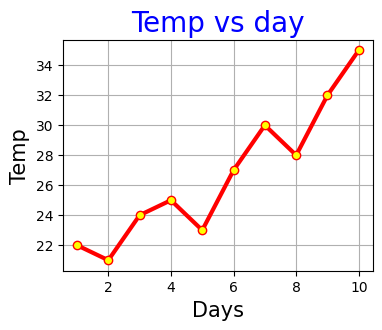

In [ ]:
days=[1,2,3,4,5,6,7,8,9,10]
temp=[22,21,24,25,23,27,30,28,32,35]


# Figure size
#        figsize=(width,length)
plt.figure(figsize=(4,3))
# plt.plot(x_axis,y_axis,......customizations)
plt.plot(days,temp,color="red",linewidth=3,marker="o",markerfacecolor="yellow")
# Title
plt.title("Temp vs day",fontsize=20,color="blue")
# X label
plt.xlabel("Days",fontsize=15)
# Y label
plt.ylabel("Temp",fontsize=15)
plt.grid(True)
plt.show()

In [ ]:
x=np.array([1,2,3,4,5])
sq=[1,4,9,16,25]
cube=[1,8,27,64,125]
quad=x**4

print(quad)

[  1  16  81 256 625]


Multi Line

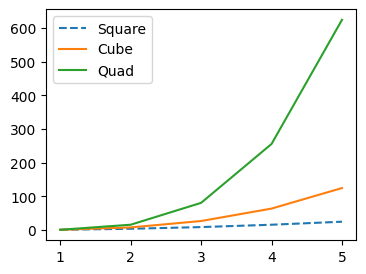

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(x,sq,label="Square",ls="--")
plt.plot(x,cube,label="Cube")
plt.plot(x,quad,label="Quad")
plt.legend() # Shows the labels
plt.show()

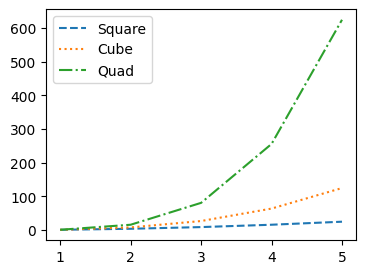

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(x,sq,label="Square",ls="--")
plt.plot(x,cube,label="Cube",ls=":")
plt.plot(x,quad,label="Quad",ls="-.")
plt.legend() # Shows the labels
plt.show()

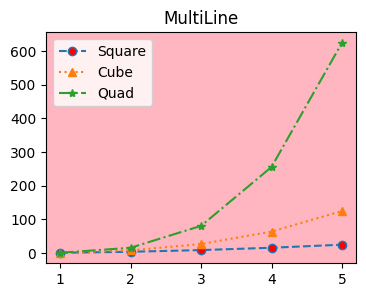

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(x,sq,label="Square",ls="--",marker="o",markerfacecolor="Red")
plt.plot(x,cube,label="Cube",ls=":",marker="^")
plt.plot(x,quad,label="Quad",ls="-.",marker="*")
plt.title("MultiLine")

# Background color -> to the plot
ax=plt.gca()
ax.set_facecolor("lightpink")

plt.legend() # Shows the labels
plt.show()

ls (linestyle)=> Line Style

"--" -> dashed

":"-> dotted

Marker styles

Marks-> data points

"o"-> circle, "s"-> square, "*"-> start, "+", "x", "^"

marker color-> markerfacecolor

flight data sets

In [ ]:
data=sb.load_dataset("flights")
data

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [ ]:
yearly=data.groupby("year")["passengers"].sum()
yearly

,passengers
year,
1949,1520
1950,1676
1951,2042
1952,2364
1953,2700
1954,2867
1955,3408
1956,3939
1957,4421


In [ ]:
x=yearly.index
x

Index([1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960], dtype='int64', name='year')

In [ ]:
y=yearly.values
y

array([1520, 1676, 2042, 2364, 2700, 2867, 3408, 3939, 4421, 4572, 5140,
       5714])

In [ ]:
plt.figure(figsize=(4,3))
plt.plot(x,y)

<Figure size 400x300 with 0 Axes>

<Figure size 400x300 with 0 Axes>

bar charts


# **Bar Chart**

Bar charts are used to compare the values of different categories, see the trend over time, and so show discrete data count.

The length of the bar, represents the value of the category.

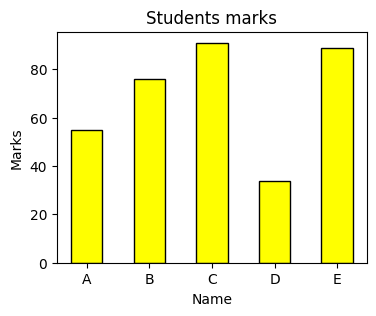

In [ ]:
plt.figure(figsize=(4,3))
name=["A","B","C","D","E"]
marks=[55,76,91,34,89]
# plt.bar(x,y.....)
plt.bar(name,marks,color="yellow",width=0.5,edgecolor="black")
plt.title("Students marks")
plt.xlabel("Name")
plt.ylabel("Marks")
plt.show()

How to add

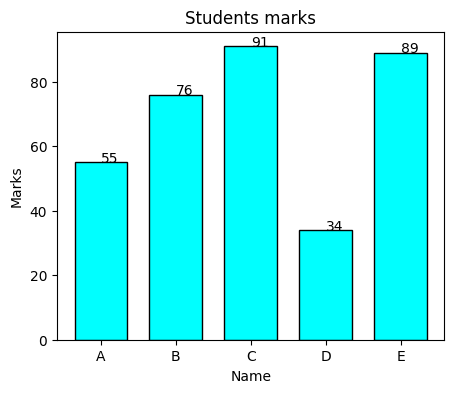

In [ ]:
plt.figure(figsize=(5,4))
name=["A","B","C","D","E"]
marks=[55,76,91,34,89]
# plt.bar(x,y.....)
bars =plt.bar(name,marks,color="cyan",width=0.7,edgecolor="black")
plt.title("Students marks")
plt.xlabel("Name")
plt.ylabel("Marks")

# Add the value on top of the bars=> plt.text(x,y= location, text(what to add))
for bar in bars:
  height=bar.get_height()
  plt.text(bar.get_x()+bar.get_width()/2,height,str(height))    # bar.get_X()-> Location of bar on X axis

plt.show()

<BarContainer object of 5 artists>

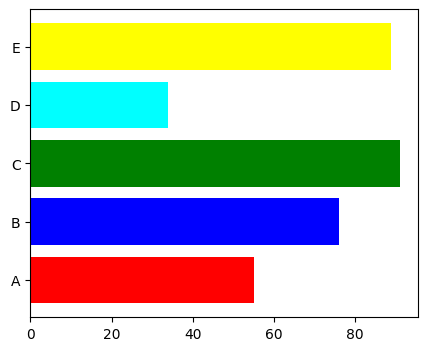

In [ ]:
plt.figure(figsize=(5,4))
name=["A","B","C","D","E"]
marks=[55,76,91,34,89]

# Horizontal Bar => plt.barh()
plt.barh(name,marks,color=["Red","Blue","Green","Cyan","Yellow"])

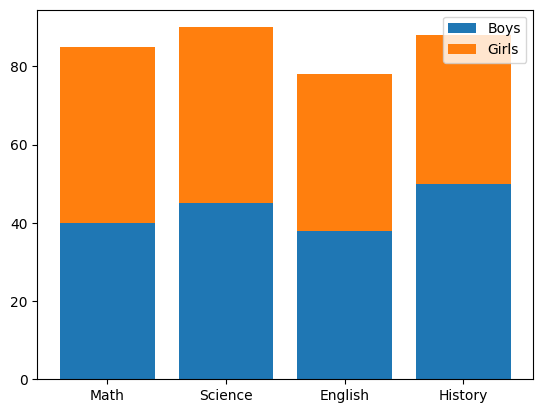

In [ ]:
# Stacked bar chart

subjects = ["Math", "Science", "English", "History"]
boys = [40, 45, 38, 50]
girls = [45, 45, 40, 38]
plt.bar(subjects,boys,label="Boys")
plt.bar(subjects,girls,bottom=boys,label="Girls")
plt.legend()
plt.show()


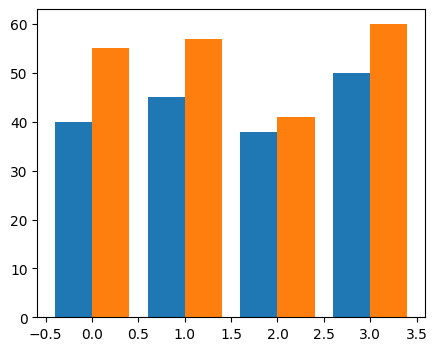

In [ ]:
# Multiple bars
plt.figure(figsize=(5,4))
x=np.arange(len(subjects))
width=0.4
# plt.bar(x,height,width)
# x-> position of bar
# height=> values

#  x-> 0,1,2,3
plt.bar(x-width/2, boys,width,label="Boys") # 0-(0.2)
plt.bar(x+width/2,girls,width,label="Girls") # 0+(0.2)
plt.legend
plt.show()



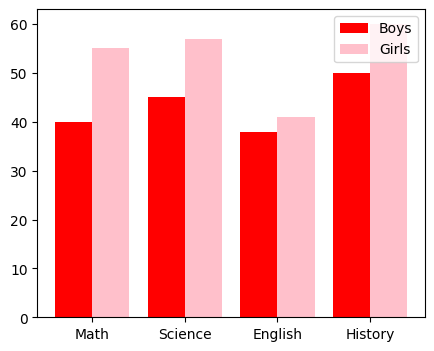

In [ ]:
# Multiple bars
plt.figure(figsize=(5,4))
x=np.arange(len(subjects))
width=0.4
# plt.bar(pos,height,width)
# pos-> position of bar
# height=> values

#  x-> 0,1,2,3
        #Position
plt.bar(x-width/2, boys,width,label="Boys",color="Red") # 0-(0.2)
plt.bar(x+width/2,girls,width,label="Girls",color="Pink") # 0+(0.2)
plt.legend()
plt.xticks(x,subjects)
plt.show()

dataset-tips

In [ ]:
Compare the total bills accross different days

In [ ]:
data=sb.load_dataset("tips")
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
data.dropna(inplace=True)

NameError: name 'data' is not defined

In [ ]:
day_tip=data.groupby("day")["tip"].sum()
print(day_tip)

day
Thur    171.83
Fri      51.96
Sat     260.40
Sun     247.39
Name: tip, dtype: float64


/tmp/ipython-input-4119122758.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_tip=data.groupby("day")["tip"].sum()


In [ ]:
x=day_tip.index
y=day_tip.values

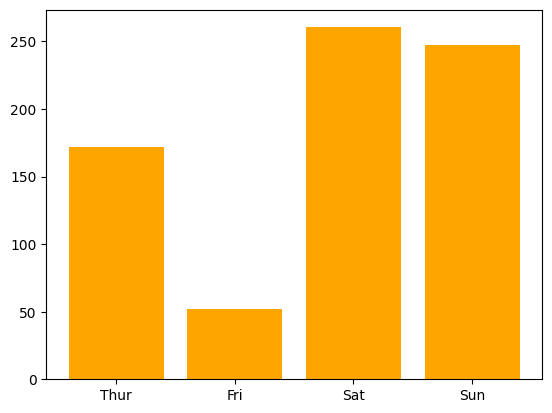

In [ ]:
plt.bar(x,y,color="Orange")
plt.show()

ScatterPlot


# **ScatterPlot**

Used to see the relationship between two variables using dots.


Used to check the the increase/decrease in one variable with respect to the other.

Eg-> Height vs bmi, Weight vs BP, Temp vs electricty bill, etc

In [ ]:
temp=np.random.randint(15,40,50)
temp

array([26, 20, 22, 15, 30, 36, 27, 21, 33, 28, 21, 17, 31, 31, 25, 28, 30,
       22, 23, 39, 23, 21, 28, 16, 37, 32, 30, 39, 28, 34, 22, 32, 18, 31,
       27, 20, 31, 20, 27, 18, 19, 15, 20, 35, 27, 26, 36, 22, 19, 22])

In [ ]:
electricty_bill=temp*500+ np.random.randint(-1000,1000)
electricty_bill

array([13618, 10618, 11618,  8118, 15618, 18618, 14118, 11118, 17118,
       14618, 11118,  9118, 16118, 16118, 13118, 14618, 15618, 11618,
       12118, 20118, 12118, 11118, 14618,  8618, 19118, 16618, 15618,
       20118, 14618, 17618, 11618, 16618,  9618, 16118, 14118, 10618,
       16118, 10618, 14118,  9618, 10118,  8118, 10618, 18118, 14118,
       13618, 18618, 11618, 10118, 11618])

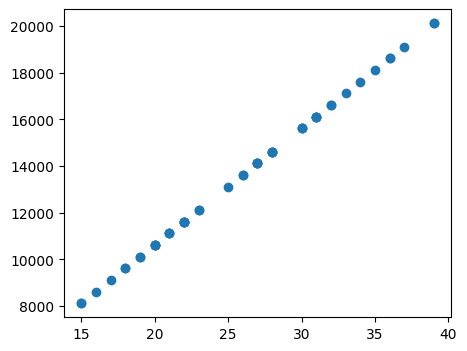

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(temp,electricty_bill)
plt.show()

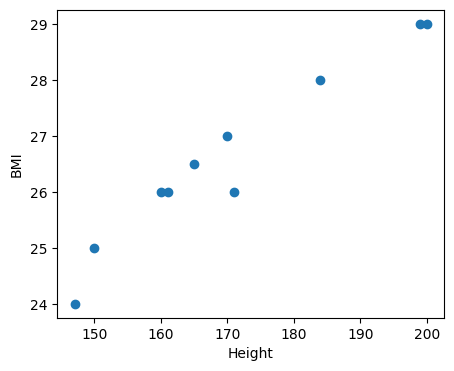

In [ ]:
plt.figure(figsize=(5,4))
height=[160,165,170,161,200,150,147,184,199,171]
bmi=[26,26.5,27,26,29,25,24,28,29,26]
plt.xlabel("Height")
plt.ylabel("BMI")
plt.scatter(height,bmi)
plt.show()

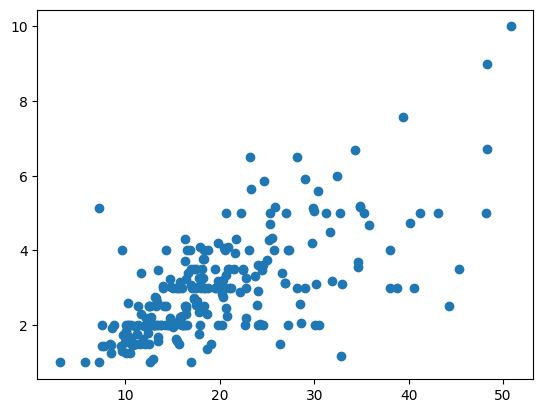

In [ ]:
plt.scatter(data["total_bill"],data["tip"])
plt.sh

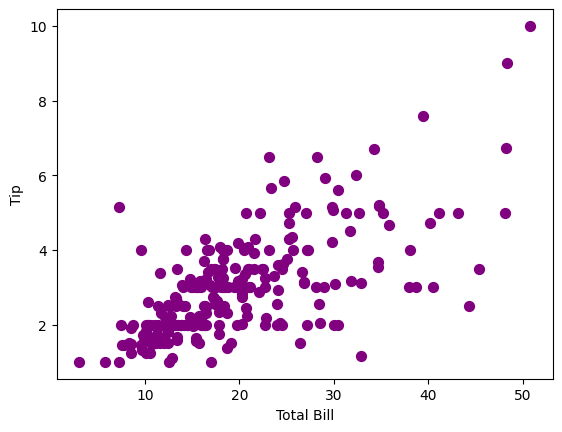

In [ ]:
plt.scatter(data["total_bill"],data["tip"],color="purple",s=50)
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

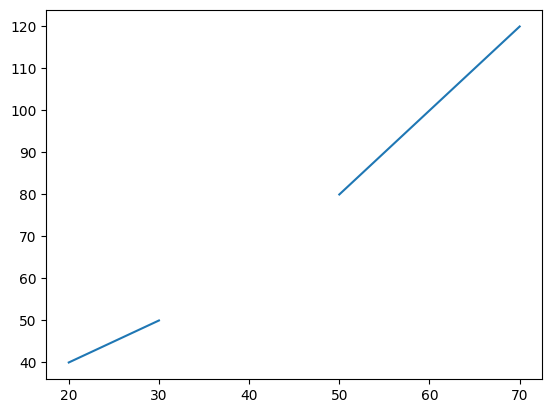

In [ ]:
time=[10,20,30,None,50,60,70]
temp=[None,40,50,60,80,100,120]
plt.plot(time,temp)

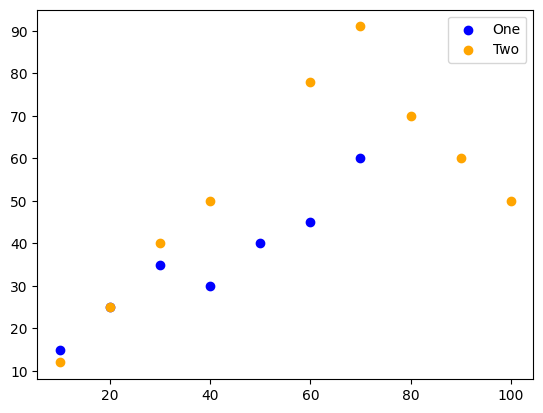

In [ ]:
x1 = [10, 20, 30, 40,50,60,70]
y1 = [15, 25, 35, 30,40,45,60]

x2 = [10, 20, 30, 40,60,70,80,90,100]
y2 = [12,25,40,50,78,91,70,60,50]

plt.scatter(x1,y1,color="Blue",label="One")
plt.scatter(x2,y2,color="Orange",label="Two")
plt.legend()
plt.show()

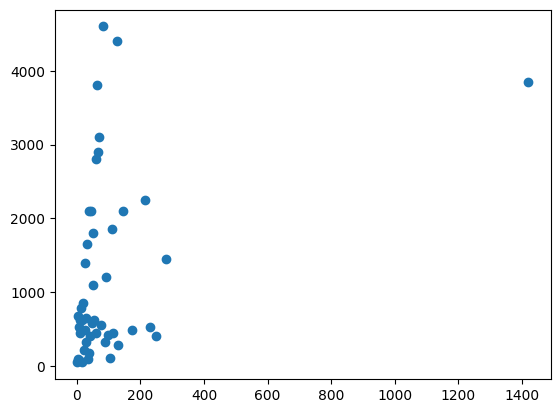

In [ ]:
population = [
    1420, 280, 250, 230, 215, 175, 145, 130,
    125, 115, 110, 105, 98, 92, 88, 84, 75, 70,
    68, 65, 62, 60, 55, 52, 50, 48, 45, 42,
    40, 38, 35, 32, 30, 28, 26, 25, 22, 20,
    18, 15, 12, 10, 9, 8, 6, 5, 4, 2
]

# GDP in Billions USD
gdp = [
    3850, 1450, 410, 520, 2250, 480, 2100, 280,
    4400, 450, 1850, 110, 420, 1200, 320, 4600, 550, 3100,
    2900, 3800, 450, 2800, 620, 1800, 1100, 580, 2100, 410,
    180, 2100, 95, 1650, 320, 650, 480, 1400, 210, 850,
    620, 55, 780, 620, 450, 520, 85, 680, 92, 45
]

plt.scatter(population,gdp)
plt.show()

Histogram
used to see the distribution of numerical data.

In [ ]:
a=np.random.randint(30,40,300)
b=np.random.randint(40,50,400)
c=np.random.randint(50,60,200)
d=np.random.randint(60,70,150)
e=np.random.randint(70,80,50)

weights=list(a)+list(b)+list(c)+list(d)+list(e)
print(weights)

[np.int64(32), np.int64(37), np.int64(31), np.int64(37), np.int64(36), np.int64(38), np.int64(31), np.int64(36), np.int64(35), np.int64(39), np.int64(33), np.int64(35), np.int64(37), np.int64(35), np.int64(32), np.int64(36), np.int64(35), np.int64(30), np.int64(37), np.int64(32), np.int64(38), np.int64(31), np.int64(36), np.int64(37), np.int64(33), np.int64(38), np.int64(39), np.int64(32), np.int64(37), np.int64(38), np.int64(34), np.int64(35), np.int64(33), np.int64(35), np.int64(34), np.int64(35), np.int64(31), np.int64(36), np.int64(38), np.int64(36), np.int64(38), np.int64(30), np.int64(34), np.int64(34), np.int64(34), np.int64(31), np.int64(39), np.int64(30), np.int64(32), np.int64(31), np.int64(31), np.int64(33), np.int64(36), np.int64(36), np.int64(33), np.int64(38), np.int64(36), np.int64(32), np.int64(30), np.int64(35), np.int64(32), np.int64(34), np.int64(38), np.int64(36), np.int64(32), np.int64(38), np.int64(36), np.int64(31), np.int64(33), np.int64(36), np.int64(31), np.in

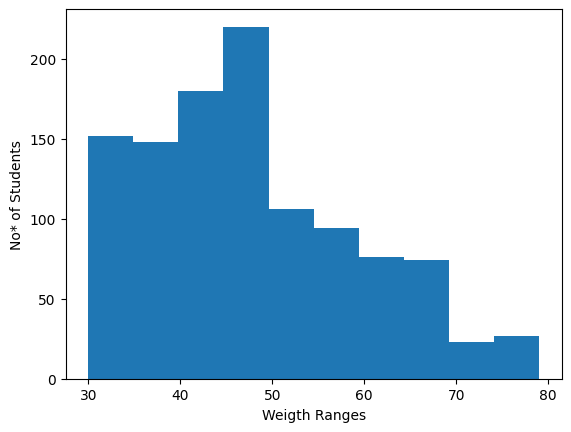

In [ ]:
plt.hist(weights)
plt.ylabel("No* of Students")
plt.xlabel("Weigth Ranges")
plt.show()

In [ ]:
data=sb.load_dataset("titanic")
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


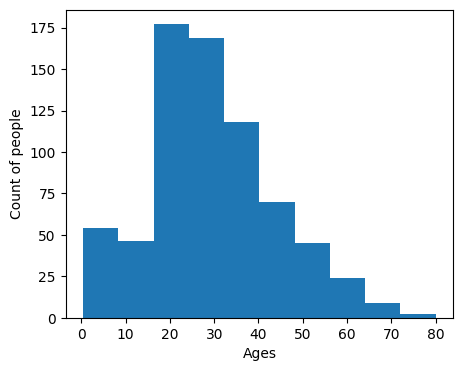

In [ ]:
plt.figure(figsize=(5,4))
plt.hist(data["age"])
plt.xlabel("Ages")
plt.ylabel("Count of people")
plt.show()

pie chart


# **Pie Chart**

Its a circular chart which is divided into slices, where each slice represents a portion(percentage) of the total.

How much each category contributes to the total.

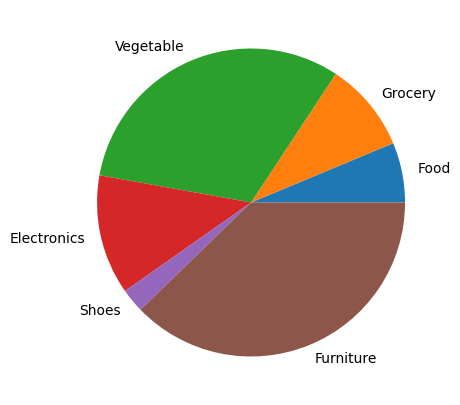

In [ ]:
items=["Food","Grocery","Vegetable","Electronics","Shoes","Furniture"]
sales=[1000,1500,5000,2000,400,6000]


plt.figure(figsize=(5,5))
plt.pie(sales,labels=items)
plt.show()

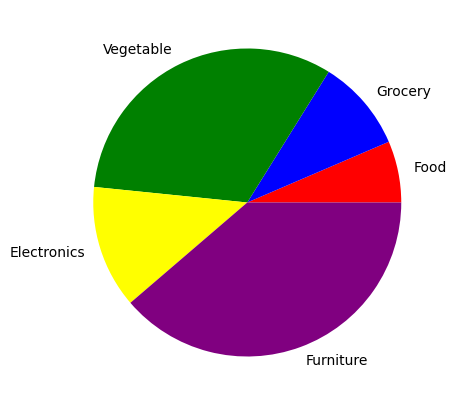

In [ ]:
items=["Food","Grocery","Vegetable","Electronics","Furniture"]
sales=[1000,1500,5000,2000,6000]


plt.figure(figsize=(5,5))
plt.pie(sales,labels=items,colors=["Red","Blue","Green","Yellow","Purple"])
plt.show()

**autopct -> %1.2f%%**

Used to show the percentage of contribution . And 2 decimal places.

%1.3f%%-> 3 decimal places

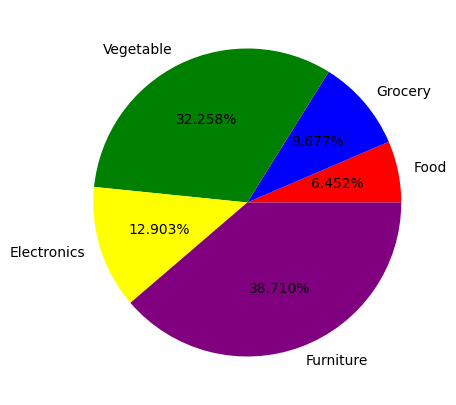

In [ ]:
items=["Food","Grocery","Vegetable","Electronics","Furniture"]
sales=[1000,1500,5000,2000,6000]


plt.figure(figsize=(5,5))
plt.pie(sales,labels=items,autopct="%1.3f%%",colors=["Red","Blue","Green","Yellow","Purple"])
plt.show()



In [ ]:
# How to add actual values.


items=["Food","Grocery","Vegetable","Electronics","Furniture"]
sales=[1000,1500,5000,2000,6000]

plt.figure(figsize=(5,5))
plt.pie(sales,labels=items,colors=["Red","Blue","Green","Yellow","Purple"])
plt.show()

NameError: name 'plt' is not defined

# Seaborn

Another library which is used for visualization.

Based on matplotlib. Seaborn makes iot easier to make plots, and makes the plots prettier.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# Scatter Plot

Used to see the relationship between variables.

In [ ]:
# sb.scatterplot(x=, y=, data=)
df=sb.load_dataset("tips")
df


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


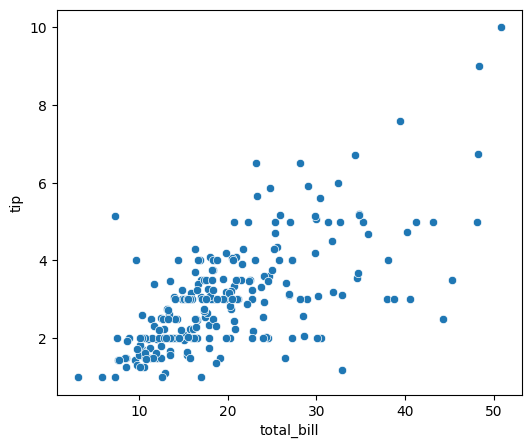

In [ ]:
# sb.scatterplot(x=, y=, data=)
plt.figure(figsize=(6,5))
# sb.scatterplot(x="total_bill",y="tip",data=df)
sb.scatterplot(x=df["total_bill"],y=df["tip"])
plt.show()

Color the points based on the sex category- male should have other color, female should have other color.

**hue**-> hue=category

Colors the chart by the category.

Different categories have different colors.

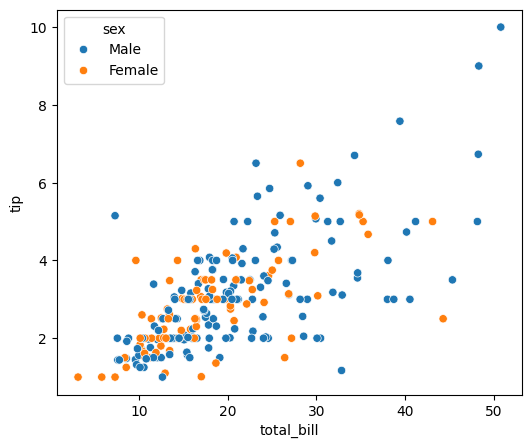

In [ ]:
plt.figure(figsize=(6,5))
sb.scatterplot(x="total_bill",y="tip",data=df,hue="sex")
plt.show()

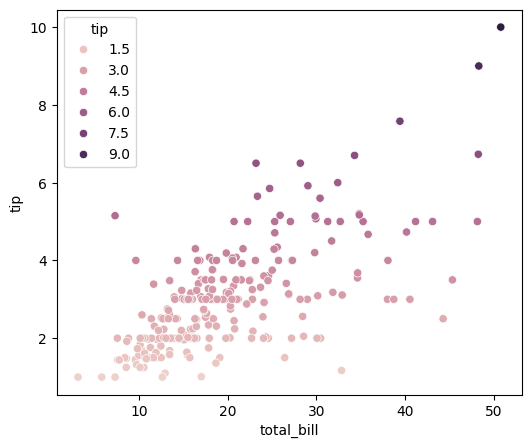

In [ ]:
plt.figure(figsize=(6,5))
sb.scatterplot(x="total_bill",y="tip",data=df,hue="tip")
plt.show()

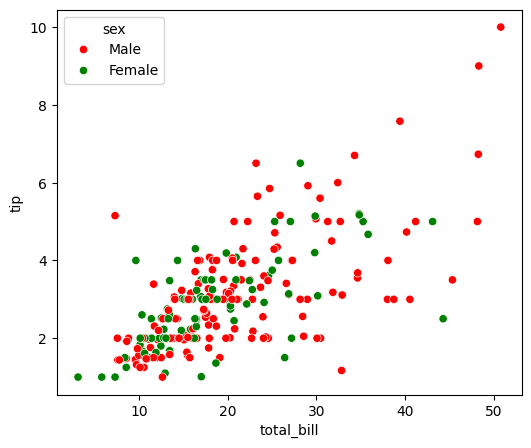

In [ ]:
plt.figure(figsize=(6,5))
sb.scatterplot(x="total_bill",y="tip",data=df,hue="sex",palette={"Male":"Red","Female":"Green"})
plt.show()

# **Line plot**

In [ ]:
df=sb.load_dataset("flights")
df

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


<Axes: xlabel='year', ylabel='passengers'>

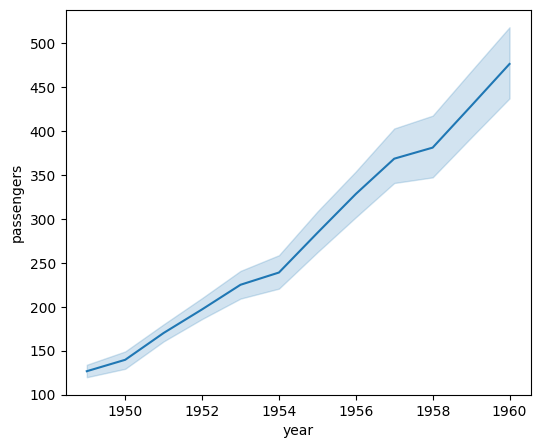

In [ ]:
plt.figure(figsize=(6,5))
sb.lineplot(x="year",y="passengers",data=df)
# by default calculates the mean or avg passengers in each year

# Shaded region is confidence interval-> the variation or spread of number of passengers


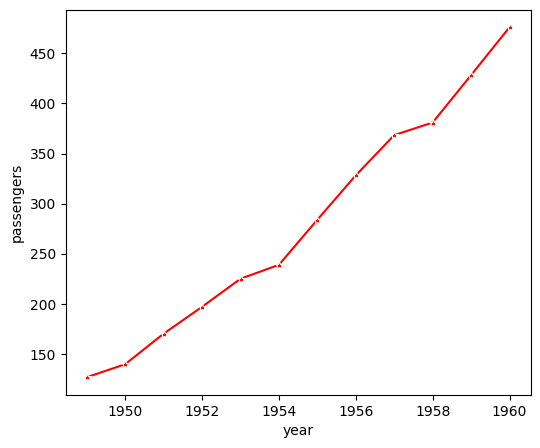

In [ ]:
# Remove the shaded region-> errorbar=None

plt.figure(figsize=(6,5))
sb.lineplot(x="year",y="passengers",data=df,errorbar=None,marker="*",color="red")
plt.show()

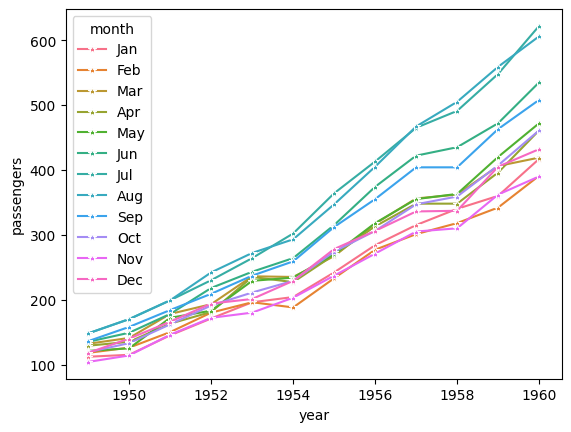

In [ ]:
# Color based on months-> hue="month"
sb.lineplot(x="year",y="passengers",data=df,errorbar=None,marker="*",color="red",hue="month")
plt.show()

# **Barchart**

In [ ]:
import pandas as pd
import numpy as np

# Define our base lists
products = ['A', 'B', 'C', 'D', 'E']
regions = ['North', 'South', 'East', 'West']

# Create 20 rows of data
df = pd.DataFrame({
    # repeating the product list 4 times to get 20 rows
    'Product': products * 4,

    # generating 20 random sales figures between 100 and 1000
    'Sales': np.random.randint(100, 1000, size=20),

    # repeating each region 5 times (or we could use np.tile)
    'Region': regions * 5
})

# Sorting by Product to make it look organized
df = df.sort_values(by='Product').reset_index(drop=True)

print(df)



   Product  Sales Region
0        A    549  North
1        A    751  South
2        A    501   East
3        A    865   West
4        B    417  South
5        B    396   East
6        B    744   West
7        B    763  North
8        C    544   East
9        C    307  South
10       C    341   West
11       C    873  North
12       D    464   West
13       D    108  North
14       D    420   East
15       D    791  South
16       E    267  South
17       E    998  North
18       E    387   East
19       E    369   West


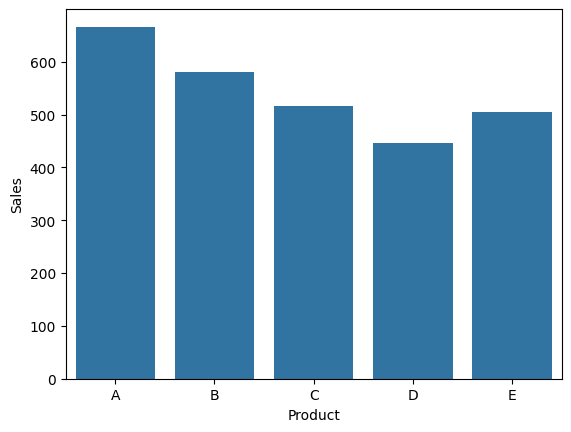

In [ ]:
sb.barplot(x="Product",y="Sales",data=df,errorbar=None)
plt.show()

# By default it calculates the avg/mean sales

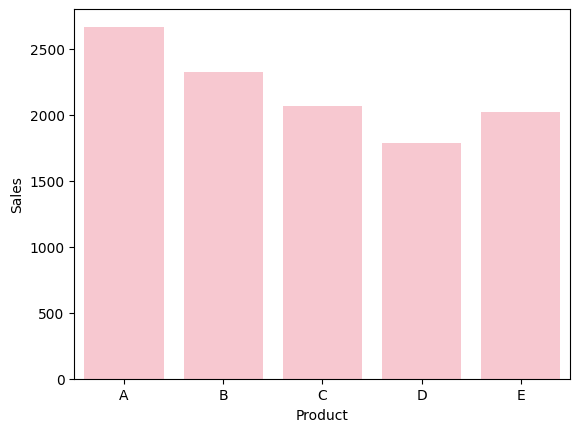

In [ ]:
# Sum of sales of each product.
# by default it is mean -> np.mean

sb.barplot(x="Product",y="Sales",data=df,errorbar=None,estimator=np.sum,color="pink")
plt.show()
# estimator-> aggregation(mean,sum,median)

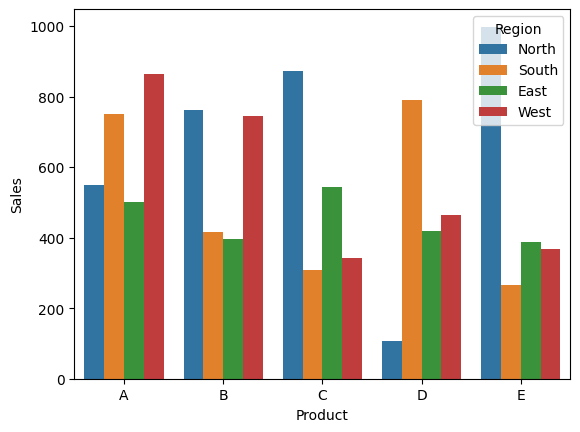

In [ ]:
# Region vise sales of the products
# hue="Region"
sb.barplot(x="Product",y="Sales",data=df,errorbar=None,estimator=np.sum,hue="Region")
plt.show()

# **Histogram**

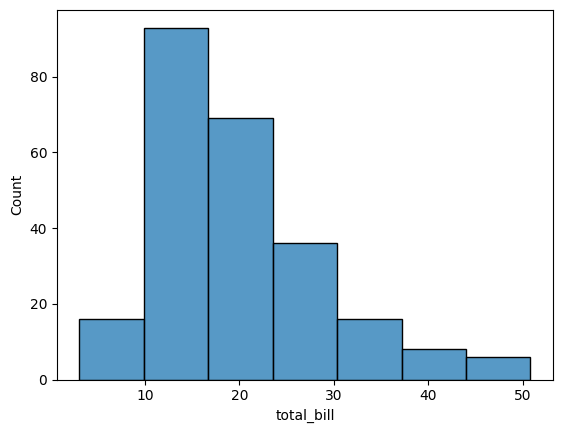

In [ ]:
df=sb.load_dataset("tips")
sb.histplot(x="total_bill",data=df,bins=7)
plt.show()

    total_bill   tip     sex smoker  day    time  size
0        16.99  1.01  Female     No  Sun  Dinner     2
1        10.34  1.66    Male     No  Sun  Dinner     3
2        21.01  3.50    Male     No  Sun  Dinner     3
3        23.68  3.31    Male     No  Sun  Dinner     2
4        24.59  3.61  Female     No  Sun  Dinner     4
5        25.29  4.71    Male     No  Sun  Dinner     4
6         8.77  2.00    Male     No  Sun  Dinner     2
7        26.88  3.12    Male     No  Sun  Dinner     4
8        15.04  1.96    Male     No  Sun  Dinner     2
9        14.78  3.23    Male     No  Sun  Dinner     2
10       10.27  1.71    Male     No  Sun  Dinner     2
11       35.26  5.00  Female     No  Sun  Dinner     4
12       15.42  1.57    Male     No  Sun  Dinner     2
13       18.43  3.00    Male     No  Sun  Dinner     4
14       14.83  3.02  Female     No  Sun  Dinner     2
15       21.58  3.92    Male     No  Sun  Dinner     2
16       10.33  1.67  Female     No  Sun  Dinner     3
17       1

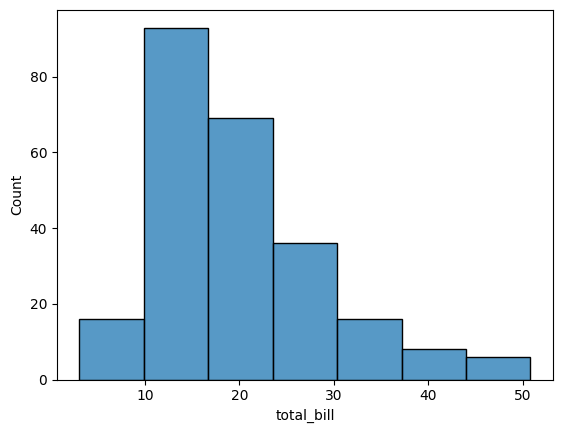

In [ ]:
df=sb.load_dataset("tips")
sb.histplot(x="total_bill",data=df,bins=7)
print(df.head(20))
plt.show()

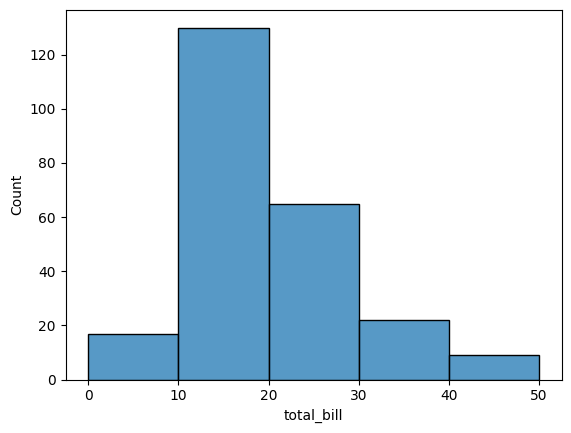

In [ ]:
df=sb.load_dataset("tips")
sb.histplot(x="total_bill",data=df,bins=[0,10,20,30,40,50])
plt.show()

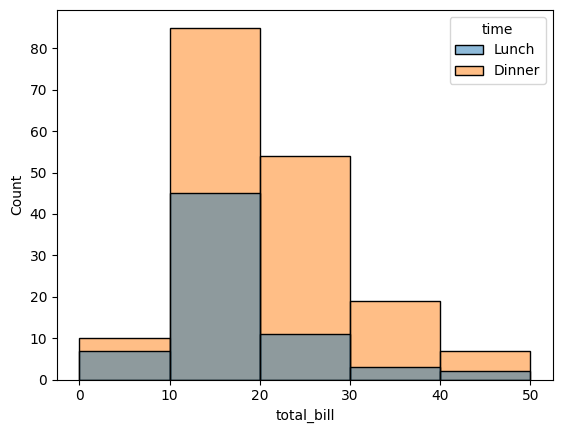

In [ ]:
# time vise distribution
# hue="time"
df=sb.load_dataset("tips")
sb.histplot(x="total_bill",data=df,bins=[0,10,20,30,40,50],hue="time")
plt.show()

# **Countplot**

Tells the count of different values in a column.

eg-> in the sex col-> tells the count of male and female

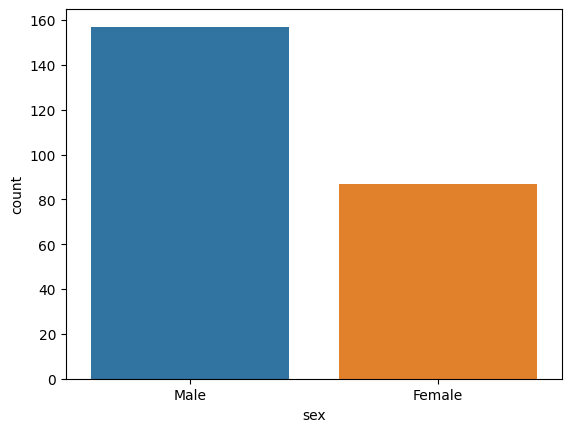

In [ ]:
sb.countplot(x="sex",data=df,hue="sex")
plt.show()

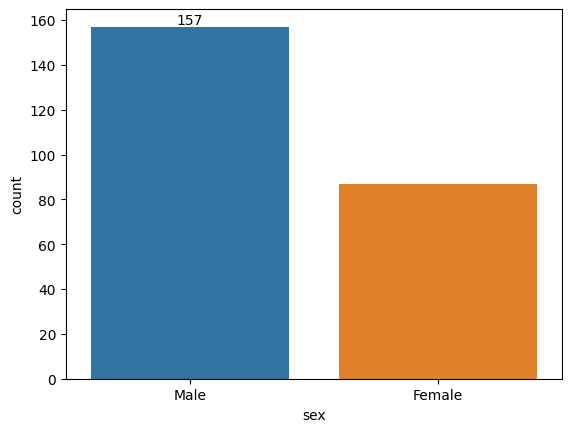

In [ ]:
graph=sb.countplot(x="sex",data=df,hue="sex")

for bar in graph.containers:
  graph.bar_label(bar)
  plt.show()

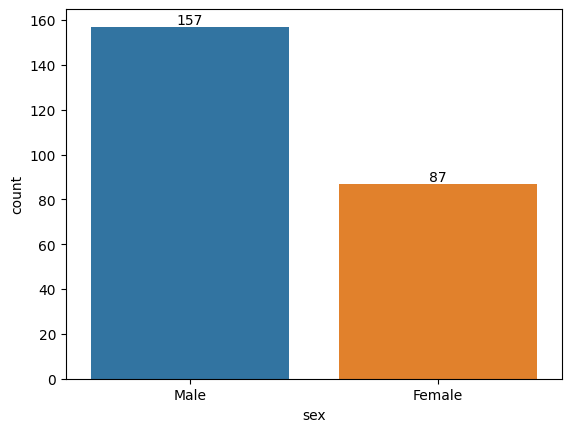

In [ ]:
graph=sb.countplot(x="sex",data=df,hue="sex")

for bar in graph.containers: # graph.containers-> all the bars of the plot
  graph.bar_label(bar)

plt.show()

# **Boxplot**

Used to see outliers.

Outlier-> extremely high or low data


In [ ]:
#Boxplot
df = pd.DataFrame({
    'Department': ['HR','HR','IT','IT','Sales','Sales','IT','HR','Sales','IT','IT'],
    'Salary': [25000, 27000, 50000, 200000, 60000, 80000, 35000, -50000, 45000, 75000,100000],
    'Gender': ['M','F','M','F','M','F','M','F','M','F','M']
})
df

,Department,Salary,Gender
0,HR,25000,M
1,HR,27000,F
2,IT,50000,M
3,IT,200000,F
4,Sales,60000,M
5,Sales,80000,F
6,IT,35000,M
7,HR,-50000,F
8,Sales,45000,M
9,IT,75000,F


<Axes: ylabel='Salary'>

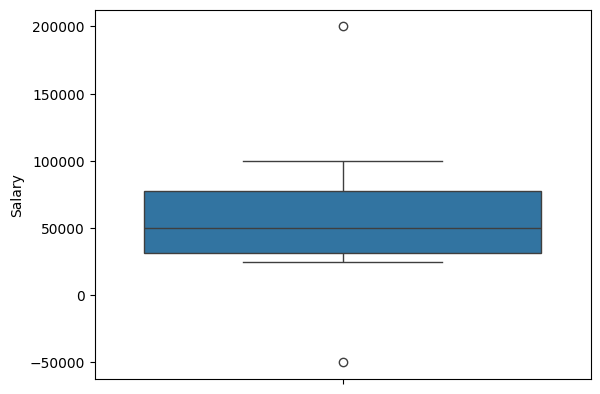

In [ ]:
sb.boxplot(y=df["Salary"])

<Axes: ylabel='Salary'>

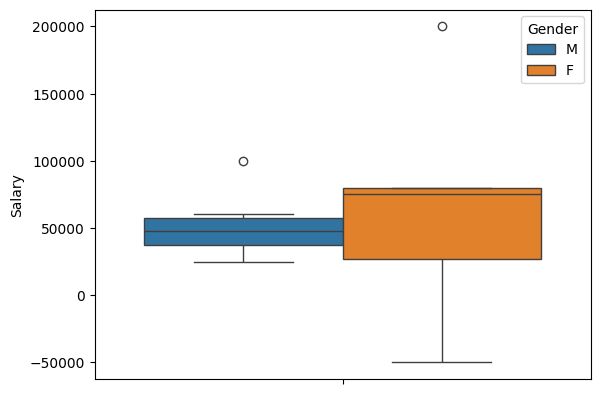

In [ ]:
sb.boxplot(y=df["Salary"],hue=df["Gender"])

# Subplots

Have multiple charts in a single page

In [ ]:
df=sb.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


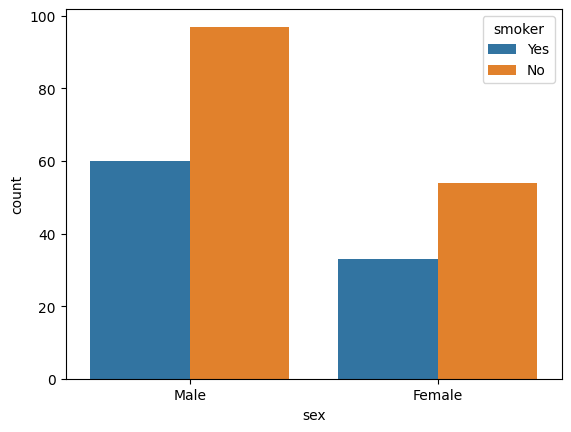

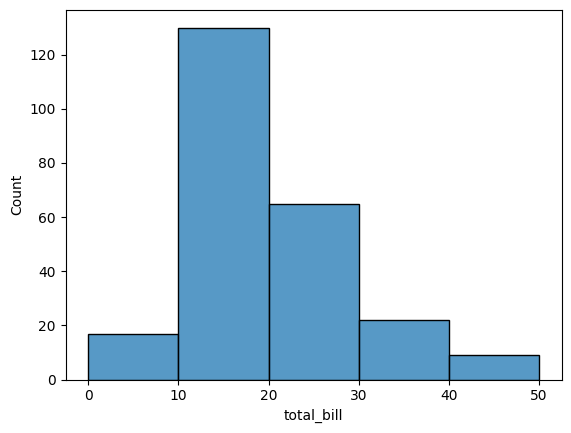

In [ ]:


# Chart1
plt.subplot()  # rows
sb.countplot(x="sex",data=df,hue="smoker")
plt.show()

# Chart2
df=sb.load_dataset("tips")
sb.histplot(x="total_bill",data=df,bins=[0,10,20,30,40,50])
plt.show()

# Penguins dataset

In [ ]:
df=sb.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
print(df.isna().sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


1, Create a histogram to show the distribution of body_mass, number of bins=20

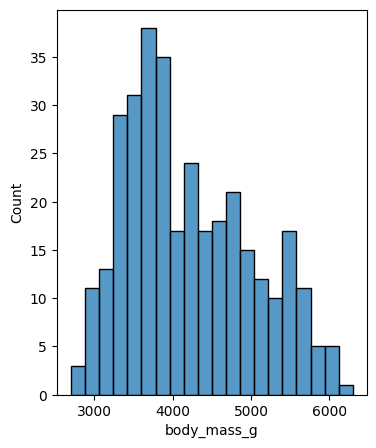

In [ ]:
plt.figure(figsize=(4,5))
sb.histplot(data=df,x="body_mass_g",bins=20)
plt.show()

**2) Pie chart for the proportion of penguins in each species(Number of penguins in each species**

**Add a title to the chart.**

**Add percentage to the slices**

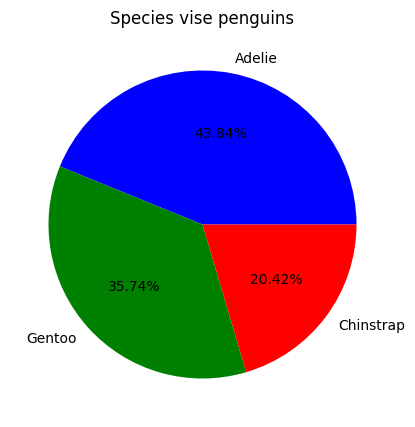

In [ ]:
count=df["species"].value_counts()
count
plt.figure(figsize=(5,5))
plt.title("Species vise penguins")
plt.pie(count,labels=count.index,autopct="%1.2f%%",colors=['Blue', 'Green', 'Red'])
plt.show()

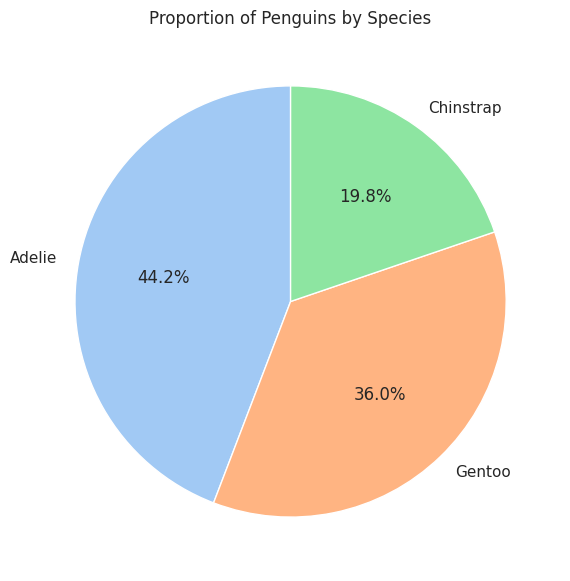

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

# Load dataset
df = sb.load_dataset("penguins")

# Count penguins per species
species_counts = df["species"].value_counts()

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(
    species_counts,
    labels=species_counts.index,
    autopct="%1.1f%%",   # show percentages
    startangle=90,       # rotate for better layout
    colors=sb.color_palette("pastel")  # optional styling
)

plt.title("Proportion of Penguins by Species")
plt.show()


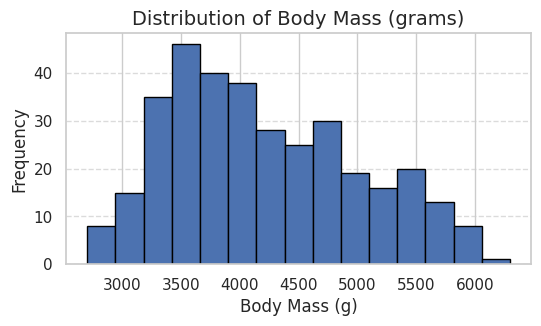

In [ ]:
plt.figure(figsize=(6,3))


plt.hist(df["body_mass_g"], bins=15, edgecolor='black')
plt.title("Distribution of Body Mass (grams)", fontsize=14)
plt.xlabel("Body Mass (g)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

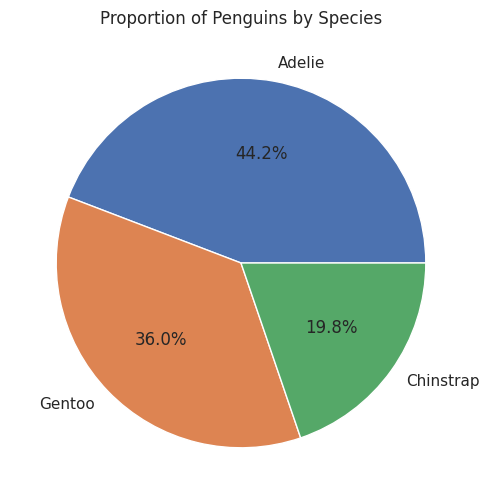

In [ ]:
species_counts = df['species'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(species_counts,labels=species_counts.index,autopct='%1.1f%%')
plt.title("Proportion of Penguins by Species")
plt.show()

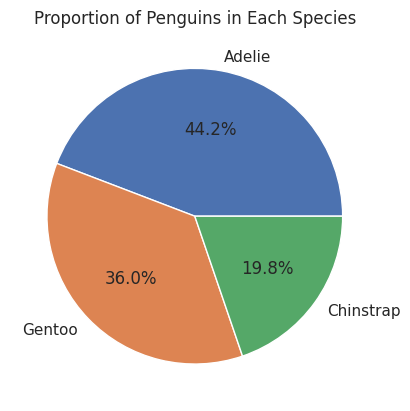

In [ ]:
scount = df['species'].value_counts()
plt.pie(scount, autopct='%1.1f%%', labels=scount.index)
plt.title("Proportion of Penguins in Each Species")
plt.show()

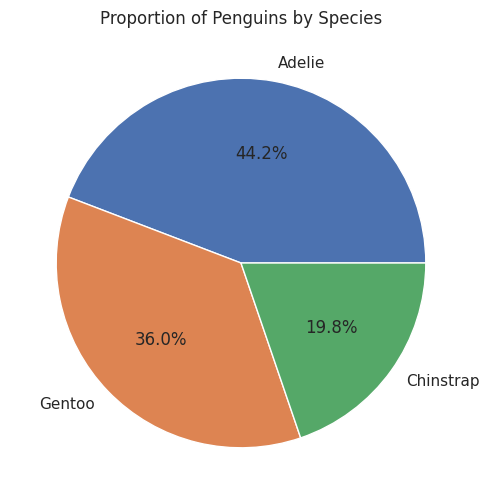

In [ ]:
species_counts = df['species'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    species_counts,
    labels=species_counts.index,
    autopct='%1.1f%%'  # shows percentages on slices
)

plt.title("Proportion of Penguins by Species")
plt.show()

3, Show the relationship between body mass and flipper length

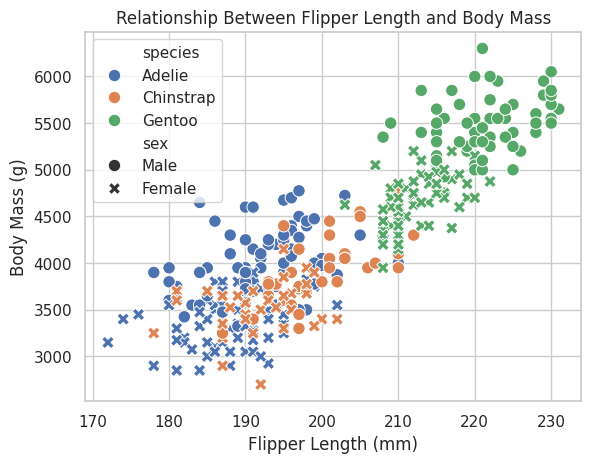

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

# Load dataset
df = sb.load_dataset("penguins")

# Scatter plot
sb.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",        # color by species (optional but helpful)
    style="sex",          # differentiate male/female (optional)
    s=80                  # point size
)

plt.title("Relationship Between Flipper Length and Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()


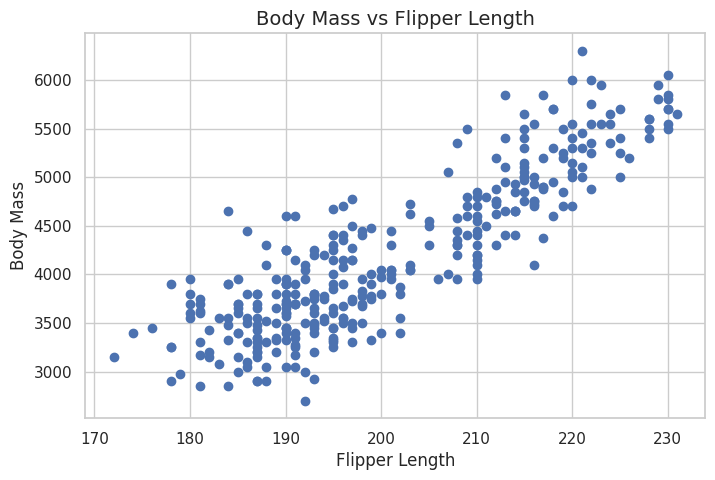

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['flipper_length_mm'], df['body_mass_g'])
plt.title("Body Mass vs Flipper Length", fontsize=14)
plt.xlabel("Flipper Length", fontsize=12)
plt.ylabel("Body Mass", fontsize=12)
plt.show()

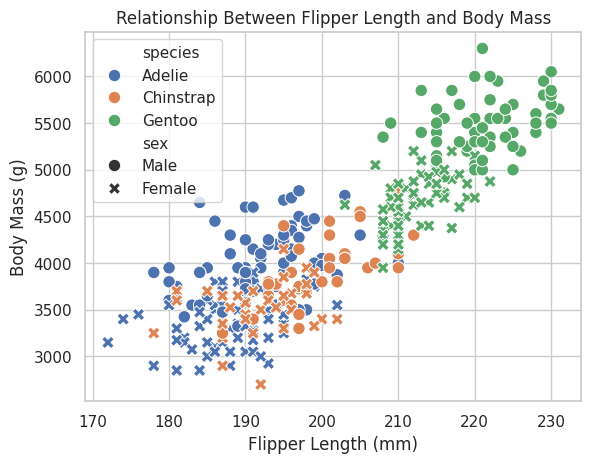

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

# Load dataset
df = sb.load_dataset("penguins")

# Scatter plot
sb.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",        # color by species (optional but helpful)
    style="sex",          # differentiate male/female (optional)
    s=80                  # point size
)

plt.title("Relationship Between Flipper Length and Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()


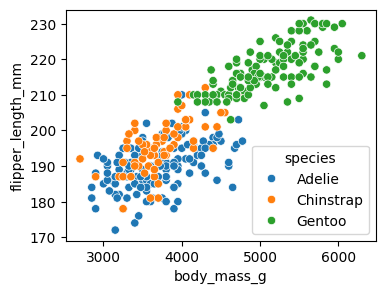

In [ ]:
plt.figure(figsize=(4,3))
sb.scatterplot(data=df,x="body_mass_g",y="flipper_length_mm",hue="species")
plt.show()

4, Find the avg body_mass of islands and show the comparison using a horizontal bar chart give the bars different color, width

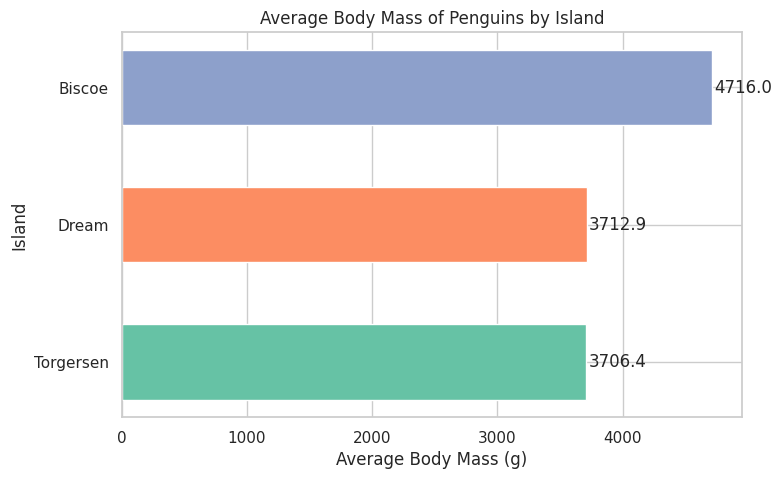

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

# Load dataset
df = sb.load_dataset("penguins")

# Calculate average body mass per island
avg_mass = df.groupby("island")["body_mass_g"].mean().sort_values()

# Plot horizontal bar chart
plt.figure(figsize=(8, 5))

plt.barh(
    avg_mass.index,
    avg_mass.values,
    color=sb.color_palette("Set2"),   # different colors for each bar
    height=0.55                       # bar thickness (width)
)

plt.title("Average Body Mass of Penguins by Island")
plt.xlabel("Average Body Mass (g)")
plt.ylabel("Island")

# Add value labels on bars
for i, value in enumerate(avg_mass.values):
    plt.text(value + 20, i, f"{value:.1f}", va='center')

plt.show()


5, check of otliers in the body_mass column, for each species(hue)

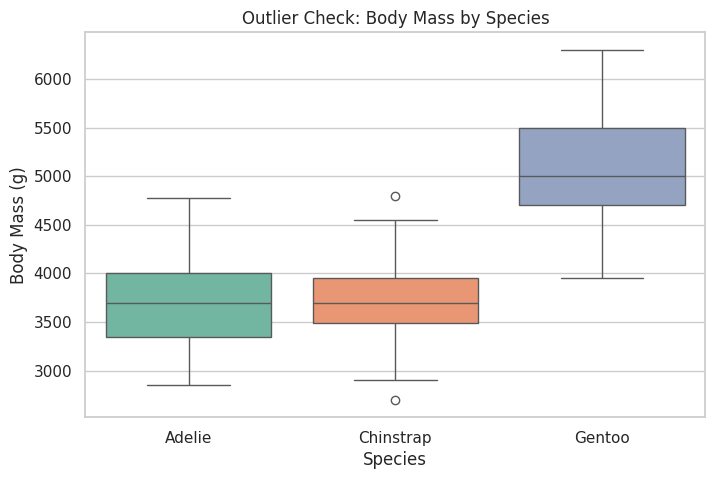

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

# Load dataset
df = sb.load_dataset("penguins")

# Boxplot to check outliers by species
plt.figure(figsize=(8, 5))

sb.boxplot(
    data=df,
    x="species",
    y="body_mass_g",
    hue="species",          # color by species
    palette="Set2"          # clean categorical palette
)

plt.title("Outlier Check: Body Mass by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.legend([],[], frameon=False)  # remove duplicate legend
plt.show()


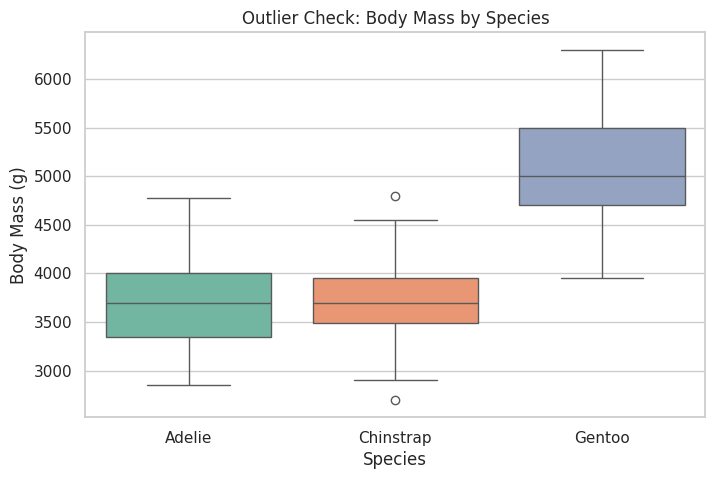

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

# Load dataset
df = sb.load_dataset("penguins")

# Boxplot to check outliers by species
plt.figure(figsize=(8, 5))

sb.boxplot(
    data=df,
    x="species",
    y="body_mass_g",
    hue="species",          # color by species
    palette="Set2"          # clean categorical palette
)

plt.title("Outlier Check: Body Mass by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.legend([],[], frameon=False)  # remove duplicate legend
plt.show()


In [ ]:
plt.figure(figsize=(5,3))

<Figure size 500x300 with 0 Axes>

<Figure size 500x300 with 0 Axes>

In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/country_profile_variables.csv')
df

,country,Region,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),"GDP growth rate (annual %, const. 2005 prices)",GDP per capita (current US$),Economy: Agriculture (% of GVA),...,Mobile-cellular subscriptions (per 100 inhabitants).1,Individuals using the Internet (per 100 inhabitants),Threatened species (number),Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI)
0,Afghanistan,SouthernAsia,652864,35530,54.4,106.3,20270,-2.4,623.2,23.3,...,8.3,42,2.1,9.8/0.3,63,5,78.2/47.0,45.1/27.0,21.43,-99
1,Albania,SouthernEurope,28748,2930,106.9,101.9,11541,2.6,3984.2,22.4,...,63.3,130,28.2,5.7/2.0,84,36,94.9/95.2,95.5/90.2,2.96,-99
2,Algeria,NorthernAfrica,2381741,41318,17.3,102.0,164779,3.8,4154.1,12.2,...,38.2,135,0.8,145.4/3.7,5900,55,84.3/81.8,89.8/82.2,0.05,-99
3,American Samoa,Polynesia,199,56,278.2,103.6,-99,-99,-99.0,-99,...,-99,92,87.9,-99,-99,-99,100.0/100.0,62.5/62.5,-99,-99
4,Andorra,SouthernEurope,468,77,163.8,102.3,2812,0.8,39896.4,0.5,...,96.9,13,34.0,0.5/6.4,1,119,100.0/100.0,100.0/100.0,-99,-99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,Wallis and Futuna Islands,Polynesia,142,12,84.1,93.4,-99,-99,-99.0,-99,...,9.0,89,41.6,~0.0/1.6,-99,26,-99,-99,-99,-99
225,Western Sahara,NorthernAfrica,266000,553,2.1,110.1,-99,-99,-99.0,-99,...,-99,49,2.7,-99,-99,-99,-99,-99,-99,-99
226,Yemen,WesternAsia,527968,28250,53.5,102.1,29688,-28.1,1106.4,14.7,...,25.1,298,1.0,22.7/0.9,668,12,72.0/46.5,92.5/34.1,2.99,-99
227,Zambia,EasternAfrica,752612,17094,23.0,98.5,21255,2.9,1311.1,8.2,...,21.0,88,65.6,4.5/0.3,374,26,85.6/51.3,55.6/35.7,3.96,-99


In [ ]:
df.head(10)

,country,Region,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),"GDP growth rate (annual %, const. 2005 prices)",GDP per capita (current US$),Economy: Agriculture (% of GVA),...,Mobile-cellular subscriptions (per 100 inhabitants).1,Individuals using the Internet (per 100 inhabitants),Threatened species (number),Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI)
0,Afghanistan,SouthernAsia,652864,35530,54.4,106.3,20270,-2.4,623.2,23.3,...,8.3,42,2.1,9.8/0.3,63,5,78.2/47.0,45.1/27.0,21.43,-99
1,Albania,SouthernEurope,28748,2930,106.9,101.9,11541,2.6,3984.2,22.4,...,63.3,130,28.2,5.7/2.0,84,36,94.9/95.2,95.5/90.2,2.96,-99
2,Algeria,NorthernAfrica,2381741,41318,17.3,102.0,164779,3.8,4154.1,12.2,...,38.2,135,0.8,145.4/3.7,5900,55,84.3/81.8,89.8/82.2,0.05,-99
3,American Samoa,Polynesia,199,56,278.2,103.6,-99,-99,-99.0,-99,...,-99,92,87.9,-99,-99,-99,100.0/100.0,62.5/62.5,-99,-99
4,Andorra,SouthernEurope,468,77,163.8,102.3,2812,0.8,39896.4,0.5,...,96.9,13,34.0,0.5/6.4,1,119,100.0/100.0,100.0/100.0,-99,-99
5,Angola,MiddleAfrica,1246700,29784,23.9,96.2,117955,3.0,4714.1,6.8,...,12.4,146,46.5,34.8/1.4,3902,25,75.4/28.2,88.6/22.5,0.42,-99
6,Anguilla,Caribbean,91,15,165.7,97.6,320,2.9,21879.6,2.3,...,76.0,52,61.1,0.1/9.8,0,136,94.6/...,97.9/...,-99,-99
7,Antigua and Barbuda,Caribbean,442,102,231.8,92.3,1356,4.1,14764.5,1.9,...,65.2,55,22.3,0.5/5.8,-99,84,97.9/97.9,91.4/91.4,0.12,-99
8,Argentina,SouthAmerica,2780400,44271,16.2,95.9,632343,2.4,14564.5,6.0,...,69.4,256,10.0,204.0/4.7,3167,85,99.0/100.0,96.2/98.3,0.01,-99
9,Armenia,WesternAsia,29743,2930,102.9,88.8,10529,3.0,3489.1,19.0,...,58.2,114,11.7,5.5/1.8,48,46,100.0/100.0,96.2/78.2,3.17,-99


In [ ]:
df.tail(10)

,country,Region,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),"GDP growth rate (annual %, const. 2005 prices)",GDP per capita (current US$),Economy: Agriculture (% of GVA),...,Mobile-cellular subscriptions (per 100 inhabitants).1,Individuals using the Internet (per 100 inhabitants),Threatened species (number),Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI)
219,Uruguay,SouthAmerica,173626,3457,19.8,93.5,53442,1.0,15573.8,6.8,...,64.6,106,10.4,6.7/2.0,113,58,100.0/93.9,96.6/92.6,0.04,-99
220,Uzbekistan,CentralAsia,448969,31911,75.0,99.4,69004,6.8,2308.3,19.2,...,42.8,59,7.6,105.2/3.6,2339,62,98.5/80.9,100.0/100.0,0.66,-99
221,Vanuatu,Melanesia,12189,276,22.7,102.4,737,-1.0,2783.0,26.7,...,22.4,137,36.1,0.2/0.6,1,12,98.9/92.9,65.1/55.4,12.32,-99
222,Venezuela (Bolivarian Republic of),SouthAmerica,912050,31977,36.3,99.0,344331,-6.2,11068.9,5.3,...,61.9,328,53.1,185.2/6.1,7460,90,95.0/77.9,97.5/69.9,0.01,-99
223,Viet Nam,South-easternAsia,330967,95541,308.1,98.0,193241,6.7,2067.9,18.9,...,52.7,616,47.2,166.9/1.8,2977,30,99.1/96.9,94.4/69.7,1.73,-99
224,Wallis and Futuna Islands,Polynesia,142,12,84.1,93.4,-99,-99,-99.0,-99,...,9.0,89,41.6,~0.0/1.6,-99,26,-99,-99,-99,-99
225,Western Sahara,NorthernAfrica,266000,553,2.1,110.1,-99,-99,-99.0,-99,...,-99,49,2.7,-99,-99,-99,-99,-99,-99,-99
226,Yemen,WesternAsia,527968,28250,53.5,102.1,29688,-28.1,1106.4,14.7,...,25.1,298,1.0,22.7/0.9,668,12,72.0/46.5,92.5/34.1,2.99,-99
227,Zambia,EasternAfrica,752612,17094,23.0,98.5,21255,2.9,1311.1,8.2,...,21.0,88,65.6,4.5/0.3,374,26,85.6/51.3,55.6/35.7,3.96,-99
228,Zimbabwe,EasternAfrica,390757,16530,42.7,95.0,13893,1.1,890.4,13.0,...,16.4,89,37.2,12.0/0.8,482,30,97.0/67.3,49.3/30.8,6.00,-99


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 50 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   country                                                     229 non-null    object 
 1   Region                                                      229 non-null    object 
 2   Surface area (km2)                                          229 non-null    object 
 3   Population in thousands (2017)                              229 non-null    int64  
 4   Population density (per km2, 2017)                          229 non-null    float64
 5   Sex ratio (m per 100 f, 2017)                               229 non-null    float64
 6   GDP: Gross domestic product (million current US$)           229 non-null    int64  
 7   GDP growth rate (annual %, const. 2005 prices)              229 non-null    object 
 8   

In [ ]:
df_sample=df.sample(30,random_state=10)
df_sample

,country,Region,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),"GDP growth rate (annual %, const. 2005 prices)",GDP per capita (current US$),Economy: Agriculture (% of GVA),...,Mobile-cellular subscriptions (per 100 inhabitants).1,Individuals using the Internet (per 100 inhabitants),Threatened species (number),Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI)
87,Guinea-Bissau,WesternAfrica,36125,1861,66.2,96.9,978,4.8,530.0,45.0,...,3.5,77,70.5,0.3/0.1,25,17,98.8/60.3,33.5/8.5,9.03,-99
26,Bosnia and Herzegovina,SouthernEurope,51209,3507,68.8,96.4,16251,3.1,4265.0,7.3,...,65.1,91,42.7,22.2/5.8,252,85,99.7/100.0,98.9/92.0,2.20,-99
76,Gambia,WesternAfrica,11295,2101,207.6,98.0,942,4.7,473.2,21.1,...,17.1,67,48.1,0.5/0.3,7,7,94.2/84.4,61.5/55.0,12.35,-99
68,Falkland Islands (Malvinas),SouthAmerica,12173,3,0.2,110.5,-99,-99,-99.0,-99,...,98.3,23,0.0,0.1/18.9,0,257,-99,-99,-99,-99
78,Germany,WesternEurope,357376,82114,235.6,97.0,3363600,1.7,41686.2,0.6,...,87.6,116,32.7,719.9/8.9,5004,158,100.0/100.0,99.3/99.0,-99,-99
149,Niue,Polynesia,260,2,6.2,100.0,-99,-99,-99.0,-99,...,79.6,52,70.0,~0.0/5.7,0,62,98.4/98.6,100.0/100.0,-99,-99
127,Martinique,Caribbean,1128,385,363.1,83.5,-99,-99,-99.0,-99,...,-99,48,45.8,2.3/5.8,1,79,100.0/99.8,94.0/72.7,-99,-99
60,Dominican Republic,Caribbean,48671,10767,222.8,99.2,67103,7.0,6373.6,6.6,...,51.9,184,40.4,21.5/2.1,28,28,85.4/81.9,86.2/75.7,0.43,-99
69,Faroe Islands,NorthernEurope,1393,49,35.3,107.2,-99,-99,-99.0,-99,...,94.2,21,0.1,0.6/12.4,1,182,-99,-99,-99,-99
124,Mali,WesternAfrica,1240192,18542,15.2,100.2,13100,7.6,744.3,39.9,...,10.3,42,3.9,1.4/0.1,55,4,96.5/64.1,37.5/16.1,9.45,-99


In [ ]:
df['Population in thousands (2017)']

,Population in thousands (2017)
0,35530
1,2930
2,41318
3,56
4,77
...,...
224,12
225,553
226,28250
227,17094


In [ ]:
#MEAN=> Sum/Length

sumCol=sum(df['Population in thousands (2017)'])
length=len(df['Population in thousands (2017)'])
print(sumCol,length)

print(f"Average Population: {sumCol/length}")

7501306 229
Average Population: 32756.794759825327


In [ ]:
df['Population in thousands (2017)'].mean()

np.float64(32756.794759825327)

In [ ]:
#MEDIAN =>
#1. sort the values
#2. fetch the mid index
#3. get the data using index fetched in the second step

In [ ]:
df['Population in thousands (2017)'].median()

5448.0

In [ ]:
#MODE => Most frequent value

df['Region'].mode()

,Region
0,Caribbean


In [ ]:
df['Region'].mode()[0]

'Caribbean'

In [ ]:
#RANGE => max-min difference

min_val=df['Population in thousands (2017)'].min()
print(f"Minimum value: {min_val}")

max_val=df['Population in thousands (2017)'].max()
print(f"Maximum value: {max_val}")

r=max_val-min_val
print("Range :", r)

Minimum value: 1
Maximum value: 1409517
Range : 1409516


In [ ]:
#Percentile- .percentile()
#Quartile

Q1=df['Population in thousands (2017)'].quantile(0.25)
print(Q1)

Q2=df['Population in thousands (2017)'].quantile(0.50)
print(Q2)

Q3=df['Population in thousands (2017)'].quantile(0.75)
print(Q3)

431.0
5448.0
19193.0


In [ ]:
#using seaborn plot a boxplot for this column 'Population in thousands (2017)'
# 8:58 PM

#Label Encoding
- Converting the object(string) type of data into numerical data so that the machines can understand it better and work with it

In [ ]:
df['Region']

,Region
0,SouthernAsia
1,SouthernEurope
2,NorthernAfrica
3,Polynesia
4,SouthernEurope
...,...
224,Polynesia
225,NorthernAfrica
226,WesternAsia
227,EasternAfrica


In [ ]:
df['Region'].nunique() #number of unique values

22

In [ ]:
df['Region'].unique() #unique values from the column

array(['SouthernAsia', 'SouthernEurope', 'NorthernAfrica', 'Polynesia',
       'MiddleAfrica', 'Caribbean', 'SouthAmerica', 'WesternAsia',
       'Oceania', 'WesternEurope', 'EasternEurope', 'CentralAmerica',
       'WesternAfrica', 'NorthernAmerica', 'SouthernAfrica',
       'South-easternAsia', 'EasternAfrica', 'NorthernEurope',
       'EasternAsia', 'Melanesia', 'Micronesia', 'CentralAsia'],
      dtype=object)

In [ ]:
df['Region'].value_counts()

,count
Region,
Caribbean,25
WesternAsia,17
EasternAfrica,16
WesternAfrica,15
SouthernEurope,15
SouthAmerica,12
NorthernEurope,12
EasternEurope,9
Polynesia,9


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
LE=LabelEncoder() #instance

In [ ]:
df['Region']=LE.fit_transform(df['Region'])

/tmp/ipython-input-278/1811384592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Region']=LE.fit_transform(df['Region'])


In [ ]:
df['Region']

,Region
0,17
1,18
2,9
3,13
4,18
...,...
224,13
225,9
226,20
227,3


In [ ]:
from sklearn.preprocessing import LabelEncoder

def label_encode_objects(df):
    """
    Takes a pandas DataFrame and label-encodes all object/string columns.
    Returns:
        df_encoded: transformed DataFrame
        encoders: dict of fitted LabelEncoders for each column
    """
    df_encoded = df.copy()
    encoders = {}

    for col in df_encoded.select_dtypes(include=['object', 'string']).columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        encoders[col] = le

    return df_encoded, encoders


In [ ]:
df2=sns.load_dataset('tips') #tips is a inbuilt dataset
df2

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
#Find the probability of the day being Sunday from the df2
#prob=fav outcomes/total outcomes
#fav=day==sunday
#total=length of day

In [ ]:
df2[df2['day']=='Sun']

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
186,20.90,3.50,Female,Yes,Sun,Dinner,3
187,30.46,2.00,Male,Yes,Sun,Dinner,5
188,18.15,3.50,Female,Yes,Sun,Dinner,3
189,23.10,4.00,Male,Yes,Sun,Dinner,3


In [ ]:
#Given that time is Dinner, what is the probability of a day being Sunday?

fav=len(df2[(df2['time']=='Dinner') & (df2['day']=='Sun')])
print(fav)

total=len(df2[df2['time']=='Dinner'])
print(total)

prob=fav/total
print(prob*100)

76
176
43.18181818181818


In [ ]:
df2[(df2['time']=='Dinner')]

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
a= df2[(df2['time']=='Dinner') & (df2['day']=='Sun')]
a

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
186,20.90,3.50,Female,Yes,Sun,Dinner,3
187,30.46,2.00,Male,Yes,Sun,Dinner,5
188,18.15,3.50,Female,Yes,Sun,Dinner,3
189,23.10,4.00,Male,Yes,Sun,Dinner,3


In [ ]:
#Given that time is Dinner, what is the probability of a day being Saturday or Friday?

In [ ]:
# Dataset Link: https://drive.google.com/file/d/1RYDIAYsstlSIZc88a7Dli0yFzjLAI2uI/view?usp=sharing

In [ ]:
#1. Download the dataset from the above mentioned link
#2. Go to files icon -> Upload icon -> Select the datatset (country_profile_variables)
#3. Import libraries
#4. Fill the path in df=pd.read_csv(' ') : to get the path
     #-> Go to Files icon -> click on 3 dots next to the dataset -> copy path and paste in the code

In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/country_profile_variables.csv')
df

,country,Region,Surface area (km2),Population in thousands (2017),"Population density (per km2, 2017)","Sex ratio (m per 100 f, 2017)",GDP: Gross domestic product (million current US$),"GDP growth rate (annual %, const. 2005 prices)",GDP per capita (current US$),Economy: Agriculture (% of GVA),...,Mobile-cellular subscriptions (per 100 inhabitants).1,Individuals using the Internet (per 100 inhabitants),Threatened species (number),Forested area (% of land area),CO2 emission estimates (million tons/tons per capita),"Energy production, primary (Petajoules)",Energy supply per capita (Gigajoules),"Pop. using improved drinking water (urban/rural, %)","Pop. using improved sanitation facilities (urban/rural, %)",Net Official Development Assist. received (% of GNI)
0,Afghanistan,SouthernAsia,652864,35530,54.4,106.3,20270,-2.4,623.2,23.3,...,8.3,42,2.1,9.8/0.3,63,5,78.2/47.0,45.1/27.0,21.43,-99
1,Albania,SouthernEurope,28748,2930,106.9,101.9,11541,2.6,3984.2,22.4,...,63.3,130,28.2,5.7/2.0,84,36,94.9/95.2,95.5/90.2,2.96,-99
2,Algeria,NorthernAfrica,2381741,41318,17.3,102.0,164779,3.8,4154.1,12.2,...,38.2,135,0.8,145.4/3.7,5900,55,84.3/81.8,89.8/82.2,0.05,-99
3,American Samoa,Polynesia,199,56,278.2,103.6,-99,-99,-99.0,-99,...,-99,92,87.9,-99,-99,-99,100.0/100.0,62.5/62.5,-99,-99
4,Andorra,SouthernEurope,468,77,163.8,102.3,2812,0.8,39896.4,0.5,...,96.9,13,34.0,0.5/6.4,1,119,100.0/100.0,100.0/100.0,-99,-99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224,Wallis and Futuna Islands,Polynesia,142,12,84.1,93.4,-99,-99,-99.0,-99,...,9.0,89,41.6,~0.0/1.6,-99,26,-99,-99,-99,-99
225,Western Sahara,NorthernAfrica,266000,553,2.1,110.1,-99,-99,-99.0,-99,...,-99,49,2.7,-99,-99,-99,-99,-99,-99,-99
226,Yemen,WesternAsia,527968,28250,53.5,102.1,29688,-28.1,1106.4,14.7,...,25.1,298,1.0,22.7/0.9,668,12,72.0/46.5,92.5/34.1,2.99,-99
227,Zambia,EasternAfrica,752612,17094,23.0,98.5,21255,2.9,1311.1,8.2,...,21.0,88,65.6,4.5/0.3,374,26,85.6/51.3,55.6/35.7,3.96,-99


Exploratory Data Analysis

In [ ]:
# DataSet Link: https://drive.google.com/file/d/1zFZRmq87wTIfk6RphEoF3HaaC7d4P7Fj/view?usp=sharing

In [ ]:
#1. Upload the dataset to Files
#2. Import Libraries
#3. Read the file into a variable

In [ ]:
#EDA : Exploratory Data Analysis
#1. null values
#2. duplicate values
#3. outliers
#4. label encoding(.classes_)
    #-research and try printing "category -> number"

In [ ]:
#9:12 PM DEADLINE

In [ ]:
# DataSet Link: https://drive.google.com/file/d/1zFZRmq87wTIfk6RphEoF3HaaC7d4P7Fj/view?usp=sharing

# Create two matrix of 3x3
# Addition, Subtraction, Multiplication, division

In [ ]:
import numpy as np
import numpy as np

A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

B = np.array([
    [9, 8, 7],
    [6, 5, 4],
    [3, 2, 1]
])


In [ ]:
add_result = A + B
add_result


array([[10, 10, 10],
       [10, 10, 10],
       [10, 10, 10]])

In [ ]:
sub_result = A - B
sub_result


array([[-8, -6, -4],
       [-2,  0,  2],
       [ 4,  6,  8]])

In [ ]:
mul_result = A * B
mul_result


array([[ 9, 16, 21],
       [24, 25, 24],
       [21, 16,  9]])

In [ ]:
dot_result = A @ B
dot_result


array([[ 30,  24,  18],
       [ 84,  69,  54],
       [138, 114,  90]])

In [ ]:
div_result = A / B
div_result


array([[0.11111111, 0.25      , 0.42857143],
       [0.66666667, 1.        , 1.5       ],
       [2.33333333, 4.        , 9.        ]])

transpose of a transpose matrix is the original matrix

In [ ]:
#np.array_equal()

In [ ]:
A = np.random.randint(10,30, size=(3,3))
A

array([[12, 26, 27],
       [26, 23, 10],
       [20, 12, 12]])

In [ ]:
trans_A = A.T

determinant of the matrix

In [ ]:
import numpy as np

M = np.random.randint(10, 50, size=(4,4))
det = np.linalg.det(M)
det


np.float64(-205742.99999999997)

EDA

In [ ]:
#load the dataset

# EDA (Exploratory Data Analysis) -> Understand The Data -> Visualize the data
# Detecting Null Values -> EDA
# Detecting Duplicates -> EDA
# Detecting Outliers -> EDA
# Detecting if there is any trend in your data or not

In [ ]:
# Dataset link -> https://drive.google.com/file/d/1s-k6UuNoISCD1vBeb0c7c7CgeSHYeCm8/view

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/vgsales (1).csv")

In [ ]:
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [ ]:
df.head(7)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01


In [ ]:
df.tail(9)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16589,16592,Chou Ezaru wa Akai Hana: Koi wa Tsuki ni Shiru...,PSV,2016.0,Action,dramatic create,0.00,0.00,0.01,0.0,0.01
16590,16593,Eiyuu Densetsu: Sora no Kiseki Material Collec...,PSP,2007.0,Role-Playing,Falcom Corporation,0.00,0.00,0.01,0.0,0.01
16591,16594,Myst IV: Revelation,PC,2004.0,Adventure,Ubisoft,0.01,0.00,0.00,0.0,0.01
16592,16595,Plushees,DS,2008.0,Simulation,Destineer,0.01,0.00,0.00,0.0,0.01
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.0,0.01


In [ ]:
df.sample(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
526,527,Yoshi's Island DS,DS,2006.0,Platform,Nintendo,1.47,0.07,1.10,0.15,2.80
11935,11937,Operation Darkness,X360,2007.0,Role-Playing,Success,0.07,0.00,0.00,0.00,0.07
11671,11673,Dragon Force II: Kamisarishi Daichi ni,SAT,1998.0,Strategy,Sega,0.00,0.00,0.08,0.00,0.08
5989,5991,FlatOut: Head On,PSP,2008.0,Racing,Empire Interactive,0.13,0.11,0.00,0.06,0.29
2078,2080,Dark Souls,X360,2011.0,Role-Playing,Namco Bandai Games,0.64,0.28,0.00,0.08,1.00
13393,13395,Lux-Pain,DS,2008.0,Adventure,Rising Star Games,0.04,0.00,0.00,0.00,0.05
6748,6750,Hasbro Family Game Night 3,PS3,2010.0,Misc,Electronic Arts,0.18,0.04,0.00,0.03,0.25
15833,15836,Kao the Kangaroo Round 2,GC,2005.0,Platform,JoWood Productions,0.01,0.00,0.00,0.00,0.02
14822,14825,Backyard NFL Football,Wii,2007.0,Sports,Atari,0.02,0.00,0.00,0.00,0.03
709,711,Wario Land 4,GBA,2001.0,Platform,Nintendo,0.90,0.73,0.54,0.09,2.26


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


# Could you show me the statistical information of the numeric columns
# Could you show me the statistical information of the object columns
# Could you show me the statistical information of all the columns

In [ ]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [ ]:
df.describe(include="object")

,Name,Platform,Genre,Publisher
count,16598,16598,16598,16540
unique,11493,31,12,578
top,Need for Speed: Most Wanted,DS,Action,Electronic Arts
freq,12,2163,3316,1351


In [ ]:
# Detect the Null Values
# Handle the Null Values

In [ ]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [ ]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
df['Publisher'] = df["Publisher"].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [ ]:
df["Year"].mode()[0]

np.float64(2009.0)

In [ ]:
df["Year"].value_counts()

,count
Year,
2009.0,1431
2008.0,1428
2010.0,1259
2007.0,1202
2011.0,1139
2006.0,1008
2005.0,941
2002.0,829
2003.0,775


In [ ]:
# Mode will be usefull
# Mean/Median chances of getting a decimal/fractional year

In [ ]:
df["Year"] = df["Year"].fillna(df["Year"].mode()[0])

In [ ]:
df.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [ ]:
# Detect and Handle the Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# If there is duplicates then drop them
# df.drop_duplicates(inplace=True)

In [ ]:
# detect the Outliers

In [ ]:
import pandas as pd

df = pd.read_csv('/content/vgsales (1).csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
import matplotlib.pyplot as plt


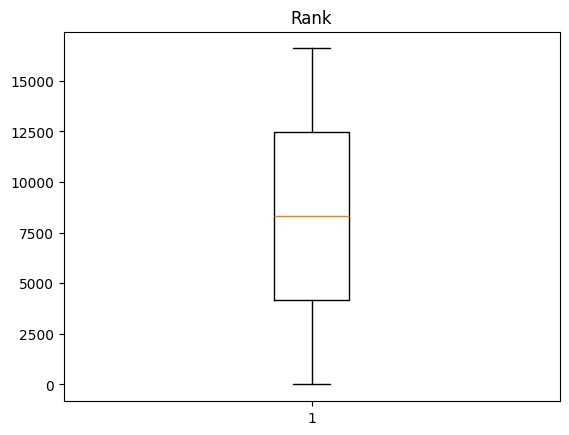

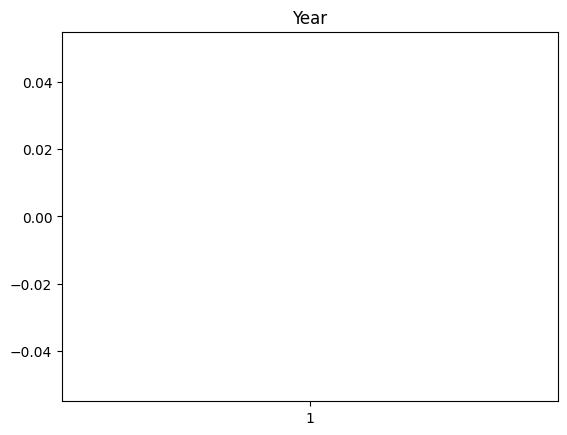

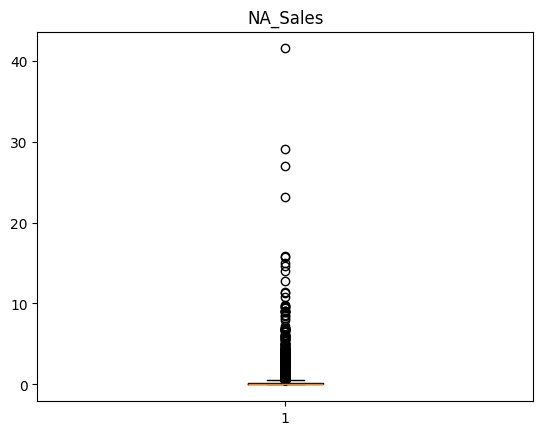

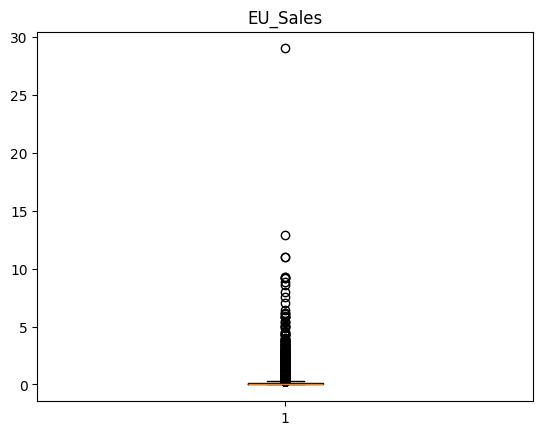

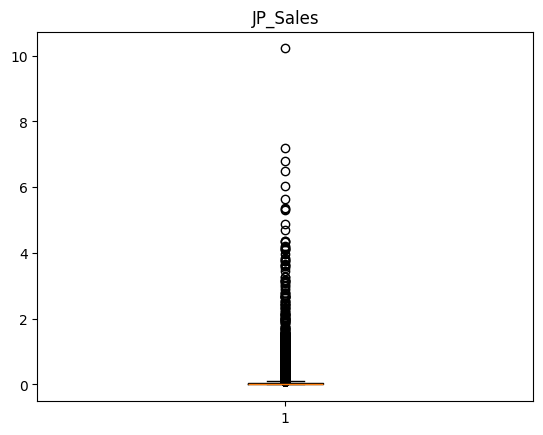

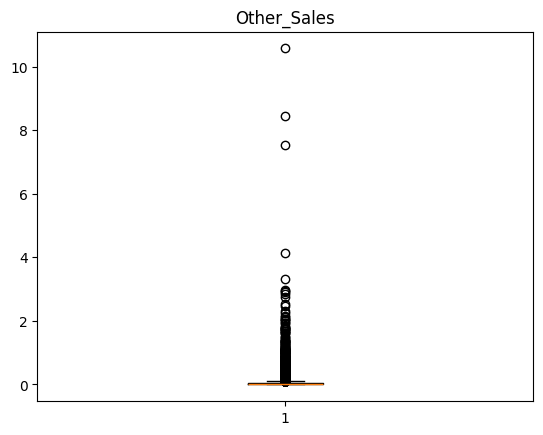

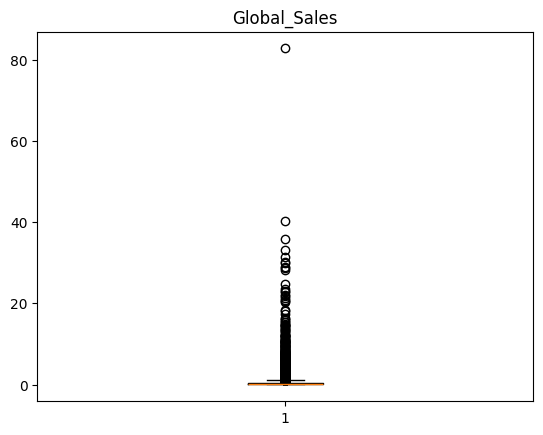

In [ ]:
for i in df.columns:
  if(df[i].dtype != "object"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [ ]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [ ]:
outliers_col = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

In [ ]:
# Remove the outliers using   IQR method from the above mentioned columns


In [ ]:
# Encoding ->

In [ ]:
# label Encoding


In [ ]:
df1 = pd.DataFrame({
    "Name" : ["Bhuvan", "Raj", "Amit", "Ranjan", "Khushi", "Ram", "Kabir"],
    "Age" : [10,20,30,40,50,60,70]
})
df1

,Name,Age
0,Bhuvan,10
1,Raj,20
2,Amit,30
3,Ranjan,40
4,Khushi,50
5,Ram,60
6,Kabir,70


In [ ]:
# lable encode the name column

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1["Name_encoded"] = le.fit_transform(df1["Name"])
print(df1)

     Name  Age  Name_encoded
0  Bhuvan   10             1
1     Raj   20             4
2    Amit   30             0
3  Ranjan   40             6
4  Khushi   50             3
5     Ram   60             5
6   Kabir   70             2


In [ ]:
# ordinal encoder
df2 = pd.DataFrame({
    "Size" : ["Small", "Medium", "Small", "Large", "Medium"]
})
df2

,Size
0,Small
1,Medium
2,Small
3,Large
4,Medium


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
oe = OrdinalEncoder(categories=[["Small", "Medium", "Large"]])
df2["Size"] = oe.fit_transform(df2[["Size"]])

In [ ]:
df2

,Size
0,Small
1,Medium
2,Small
3,Large
4,Medium


In [ ]:
df2

,Size
0,Small
1,Medium
2,Small
3,Large
4,Medium


In [ ]:
#One-Hot Encoding

In [ ]:
df1 = pd.DataFrame({
    "Name" : ["Bhuvan", "Raj", "Amit", "Ranjan", "Khushi", "Ram", "Kabir"],
    "Age" : [10,20,30,40,50,60,70],
    "Marital_Status" : ["Single", "Married", "Single", "Divorced", "Single", "Divorced", "Married"]
})
df1

,Name,Age,Marital_Status
0,Bhuvan,10,Single
1,Raj,20,Married
2,Amit,30,Single
3,Ranjan,40,Divorced
4,Khushi,50,Single
5,Ram,60,Divorced
6,Kabir,70,Married


In [ ]:
df1 = pd.get_dummies(df1, columns=["Marital_Status"])
df1

,Name,Age,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single
0,Bhuvan,10,False,False,True
1,Raj,20,False,True,False
2,Amit,30,False,False,True
3,Ranjan,40,True,False,False
4,Khushi,50,False,False,True
5,Ram,60,True,False,False
6,Kabir,70,False,True,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1['Name']=le.fit_transform(df1['Name'])
print(df1)

   Name  Age  Marital_Status_Divorced  Marital_Status_Married  \
0     1   10                    False                   False   
1     4   20                    False                    True   
2     0   30                    False                   False   
3     6   40                     True                   False   
4     3   50                    False                   False   
5     5   60                     True                   False   
6     2   70                    False                    True   

   Marital_Status_Single  
0                   True  
1                  False  
2                   True  
3                  False  
4                   True  
5                  False  
6                  False  


In [ ]:
# dataset link -> https://colab.research.google.com/drive/1IQzl_PV3mKrS_0HZVWmfsn16t0VET6v5?usp=sharing#scrollTo=AblMjQnL8Zg2

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/commodity_prices.csv")

In [ ]:
df

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1,1960-01-01,1.63,1.63,0.940900,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.066600
1,2,1960-02-01,1.63,1.63,0.946900,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.067900
2,3,1960-03-01,1.63,1.63,0.928100,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
3,4,1960-04-01,1.63,1.63,0.930300,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.068100
4,5,1960-05-01,1.63,1.63,0.920000,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
...,...,...,...,...,...,...,...,...,...,...,...,...
751,752,2022-08-01,98.60,97.75,5.917861,2.417366,4.210000,3.538154,2.360000,0.330773,0.782199,0.393525
752,753,2022-09-01,90.16,90.63,5.897138,2.455065,4.490000,3.153198,2.360000,0.323621,0.770956,0.390659
753,754,2022-10-01,93.13,90.59,5.292852,2.270979,4.135621,2.833112,2.457500,0.320943,0.762578,0.386911
754,755,2022-11-01,91.07,86.28,4.715462,2.041258,3.831528,2.849979,2.490000,0.332993,0.792340,0.407414


In [ ]:
print(df.to_string())

     Unnamed: 0        date   oil_brent   oil_dubai  coffee_arabica  coffee_robustas  tea_columbo  tea_kolkata  tea_mombasa  sugar_eu  sugar_us  sugar_world
0             1  1960-01-01    1.630000    1.630000        0.940900         0.696864     0.930301     1.121401     1.037400  0.122356  0.116845     0.066600
1             2  1960-02-01    1.630000    1.630000        0.946900         0.688707     0.930301     1.121401     1.037400  0.122356  0.119049     0.067900
2             3  1960-03-01    1.630000    1.630000        0.928100         0.688707     0.930301     1.121401     1.037400  0.122356  0.121254     0.068300
3             4  1960-04-01    1.630000    1.630000        0.930300         0.684519     0.930301     1.121401     1.037400  0.122356  0.123459     0.068100
4             5  1960-05-01    1.630000    1.630000        0.920000         0.690692     0.930301     1.121401     1.037400  0.122356  0.121254     0.068300
5             6  1960-06-01    1.630000    1.630000       

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       756 non-null    int64  
 1   date             756 non-null    object 
 2   oil_brent        756 non-null    float64
 3   oil_dubai        756 non-null    float64
 4   coffee_arabica   756 non-null    float64
 5   coffee_robustas  756 non-null    float64
 6   tea_columbo      756 non-null    float64
 7   tea_kolkata      756 non-null    float64
 8   tea_mombasa      756 non-null    float64
 9   sugar_eu         756 non-null    float64
 10  sugar_us         756 non-null    float64
 11  sugar_world      756 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 71.0+ KB


In [ ]:
# Drop the Unnamed: 0 columns

In [ ]:
df.columns

Index(['Unnamed: 0', 'date', 'oil_brent', 'oil_dubai', 'coffee_arabica',
       'coffee_robustas', 'tea_columbo', 'tea_kolkata', 'tea_mombasa',
       'sugar_eu', 'sugar_us', 'sugar_world'],
      dtype='object')

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df.head()

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1,1960-01-01,1.63,1.63,0.9409,0.696864,0.930301,1.121401,1.0374,0.122356,0.116845,0.0666
1,2,1960-02-01,1.63,1.63,0.9469,0.688707,0.930301,1.121401,1.0374,0.122356,0.119049,0.0679
2,3,1960-03-01,1.63,1.63,0.9281,0.688707,0.930301,1.121401,1.0374,0.122356,0.121254,0.0683
3,4,1960-04-01,1.63,1.63,0.9303,0.684519,0.930301,1.121401,1.0374,0.122356,0.123459,0.0681
4,5,1960-05-01,1.63,1.63,0.9200,0.690692,0.930301,1.121401,1.0374,0.122356,0.121254,0.0683


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       756 non-null    int64  
 1   date             756 non-null    object 
 2   oil_brent        756 non-null    float64
 3   oil_dubai        756 non-null    float64
 4   coffee_arabica   756 non-null    float64
 5   coffee_robustas  756 non-null    float64
 6   tea_columbo      756 non-null    float64
 7   tea_kolkata      756 non-null    float64
 8   tea_mombasa      756 non-null    float64
 9   sugar_eu         756 non-null    float64
 10  sugar_us         756 non-null    float64
 11  sugar_world      756 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 71.0+ KB


In [ ]:
# Convert the Date column from object to date and time format

In [ ]:
# 17-01-2026
# DD-MM-YYYY

# 01-17-2026
# MM-DD-YYYY

# 2026-01-17
# YYYY-MM-DD

In [ ]:
df.head(5)

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1,1960-01-01,1.63,1.63,0.9409,0.696864,0.930301,1.121401,1.0374,0.122356,0.116845,0.0666
1,2,1960-02-01,1.63,1.63,0.9469,0.688707,0.930301,1.121401,1.0374,0.122356,0.119049,0.0679
2,3,1960-03-01,1.63,1.63,0.9281,0.688707,0.930301,1.121401,1.0374,0.122356,0.121254,0.0683
3,4,1960-04-01,1.63,1.63,0.9303,0.684519,0.930301,1.121401,1.0374,0.122356,0.123459,0.0681
4,5,1960-05-01,1.63,1.63,0.9200,0.690692,0.930301,1.121401,1.0374,0.122356,0.121254,0.0683


In [ ]:
# YYYY-MM-DD
# format -> "%Y-%m-%d"

In [ ]:
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")

In [ ]:
df

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1,1960-01-01,1.63,1.63,0.940900,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.066600
1,2,1960-02-01,1.63,1.63,0.946900,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.067900
2,3,1960-03-01,1.63,1.63,0.928100,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
3,4,1960-04-01,1.63,1.63,0.930300,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.068100
4,5,1960-05-01,1.63,1.63,0.920000,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
...,...,...,...,...,...,...,...,...,...,...,...,...
751,752,2022-08-01,98.60,97.75,5.917861,2.417366,4.210000,3.538154,2.360000,0.330773,0.782199,0.393525
752,753,2022-09-01,90.16,90.63,5.897138,2.455065,4.490000,3.153198,2.360000,0.323621,0.770956,0.390659
753,754,2022-10-01,93.13,90.59,5.292852,2.270979,4.135621,2.833112,2.457500,0.320943,0.762578,0.386911
754,755,2022-11-01,91.07,86.28,4.715462,2.041258,3.831528,2.849979,2.490000,0.332993,0.792340,0.407414


In [ ]:
# what is the maximum price of robusta coffee and on which date

In [ ]:
df['coffee_robustas'].max()

6.883547

In [ ]:
df[df['coffee_robustas']==df['coffee_robustas'].max]

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world


In [ ]:
df[df['coffee_robustas']==df['coffee_robustas'].max()]["date"]

,date
207,1977-04-01


In [ ]:
# What is the 75th percentile price of Sugar_eu


In [ ]:
df.describe()

,Unnamed: 0,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,378.500000,32.724944,31.238130,2.576555,1.727478,1.777962,1.870308,1.671222,0.405158,0.432462,0.240263
std,218.382692,31.885368,30.936611,1.342454,0.940748,1.008679,0.697867,0.615357,0.187741,0.188589,0.151947
min,1.000000,1.210000,1.210000,0.777600,0.487210,0.434198,0.664799,0.719600,0.112215,0.116845,0.028700
25%,189.750000,10.564999,10.452500,1.351625,0.923053,0.892501,1.297369,1.136800,0.298120,0.297624,0.139705
50%,378.500000,20.489130,18.550000,2.697794,1.632172,1.504001,1.850612,1.598257,0.402343,0.471119,0.215285
75%,567.250000,47.157500,45.576023,3.312950,2.282200,2.515204,2.376899,2.083830,0.569519,0.512188,0.309325
max,756.000000,133.873043,131.224783,7.003600,6.883547,4.490000,4.073011,3.392500,0.783171,1.263247,1.237700


In [ ]:
df['sugar_eu'].quantile(0.75)

np.float64(0.56951937998)

In [ ]:
# what is the skewness of the price distribution of arabica coffee?

In [ ]:
df['coffee_arabica'].skew()

np.float64(0.5903976942861767)

In [ ]:
# Histogram ->

In [ ]:
import seaborn as sns
import matplotlib.pyplot

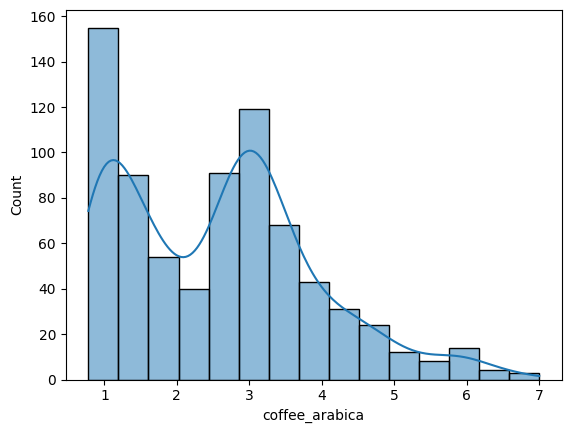

In [ ]:
sns.histplot(df['coffee_arabica'], kde=True)
plt.show()

In [ ]:
# Normal Test -> To check if data follows a normal distribution

In [ ]:
# Is the distribution of sugar price in US is signifanctly different from the normal distribution?

In [ ]:
# H0 =
# H1 =

In [ ]:
from scipy import stats

In [ ]:
test_result, p_value = stats.normaltest(df['sugar_us'])
p_value

np.float64(0.39009821516930415)

In [ ]:
if (p_value>0.05):
  print("Failed to Reject the Null Hypothesis (Normal)")
else:
  print("Reject the Null Hypothesis")

Failed to Reject the Null Hypothesis (Normal)


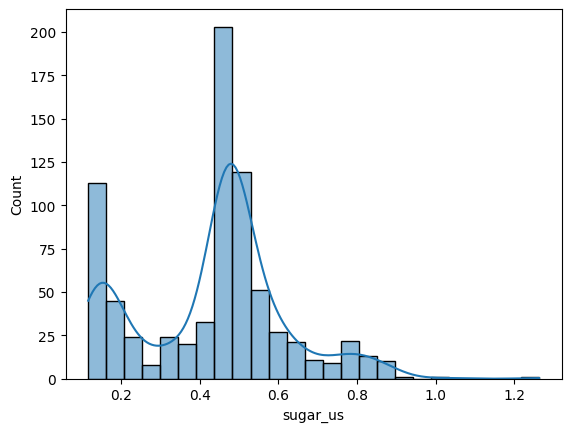

In [ ]:
sns.histplot(df['sugar_us'], kde=True)
plt.show()

In [ ]:
# how many times does the price of dubai oil exceed the price of brent oil by a certain threshold value of $o.5

In [ ]:
threshold = 0.5
count_exceed = ((df['oil_dubai'] - df['oil_brent']) > threshold).sum()

In [ ]:
df

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
0,1,1960-01-01,1.63,1.63,0.940900,0.696864,0.930301,1.121401,1.037400,0.122356,0.116845,0.066600
1,2,1960-02-01,1.63,1.63,0.946900,0.688707,0.930301,1.121401,1.037400,0.122356,0.119049,0.067900
2,3,1960-03-01,1.63,1.63,0.928100,0.688707,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
3,4,1960-04-01,1.63,1.63,0.930300,0.684519,0.930301,1.121401,1.037400,0.122356,0.123459,0.068100
4,5,1960-05-01,1.63,1.63,0.920000,0.690692,0.930301,1.121401,1.037400,0.122356,0.121254,0.068300
...,...,...,...,...,...,...,...,...,...,...,...,...
751,752,2022-08-01,98.60,97.75,5.917861,2.417366,4.210000,3.538154,2.360000,0.330773,0.782199,0.393525
752,753,2022-09-01,90.16,90.63,5.897138,2.455065,4.490000,3.153198,2.360000,0.323621,0.770956,0.390659
753,754,2022-10-01,93.13,90.59,5.292852,2.270979,4.135621,2.833112,2.457500,0.320943,0.762578,0.386911
754,755,2022-11-01,91.07,86.28,4.715462,2.041258,3.831528,2.849979,2.490000,0.332993,0.792340,0.407414


In [ ]:
df["diff"] = df["oil_dubai"] - df["oil_brent"]



count_exceed = (df["diff"] > 0.5).sum()


print("Number of times Dubai oil exceeds Brent oil by more than $0.5:", count_exceed)

Number of times Dubai oil exceeds Brent oil by more than $0.5: 8


In [ ]:
df["diff"].describe()


,diff
count,756.000000
mean,-1.486814
std,1.665441
min,-12.239048
25%,-2.404500
50%,-1.175238
75%,0.000000
max,1.500000


<Axes: title={'center': 'Dubai - Brent Price Spread'}>

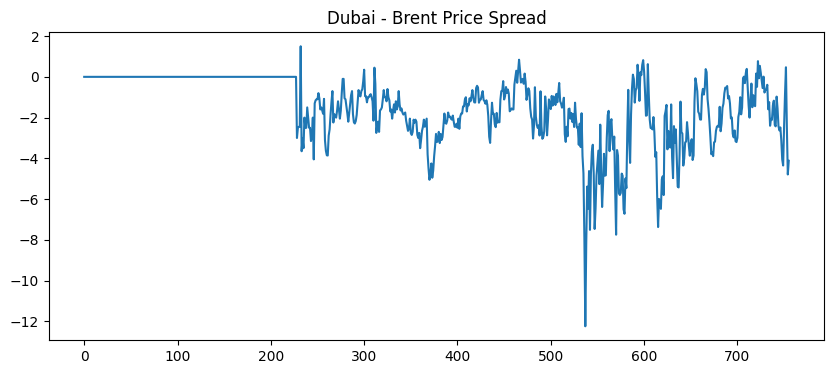

In [ ]:
df["diff"].plot(figsize=(10,4), title="Dubai - Brent Price Spread")


In [ ]:
df[df["diff"] > 0.5][["date", "oil_dubai", "oil_brent", "diff"]]


,date,oil_dubai,oil_brent,diff
232,1979-05-01,34.250000,32.750000,1.500000
466,1998-11-01,11.760000,10.920000,0.840000
593,2009-06-01,69.210909,68.616818,0.594091
598,2009-11-01,77.625238,77.036667,0.588571
599,2009-12-01,75.488636,74.669545,0.819091
604,2010-05-01,76.874000,76.250952,0.623048
722,2020-03-01,33.750000,32.980000,0.770000
724,2020-05-01,31.560000,31.020000,0.540000


In [ ]:
ans_df = df[df['oil_dubai'] > df['oil_brent']+0.5]
ans_df

,Unnamed: 0,date,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world,diff
232,233,1979-05-01,32.750000,34.250000,3.302300,3.255800,0.522197,2.186726,1.603823,0.367731,0.315922,0.173100,1.500000
466,467,1998-11-01,10.920000,11.760000,2.565500,1.767200,1.876100,1.928400,1.588000,0.607600,0.481300,0.177700,0.840000
593,594,2009-06-01,68.616818,69.210909,3.302300,1.626789,3.136443,2.800668,2.407500,0.553510,0.491530,0.362219,0.594091
598,599,2009-11-01,77.036667,77.625238,3.355652,1.531770,3.349507,2.912281,2.906000,0.496348,0.702458,0.490748,0.588571
599,600,2009-12-01,74.669545,75.488636,3.486816,1.540721,3.267095,2.676978,2.976667,0.489241,0.734209,0.518747,0.819091
604,605,2010-05-01,76.250952,76.874000,3.820166,1.556682,3.218563,2.847987,2.330000,0.420977,0.681062,0.335102,0.623048
722,723,2020-03-01,32.980000,33.750000,3.270113,1.487237,3.080000,1.327757,1.994000,0.361306,0.597232,0.260807,0.770000
724,725,2020-05-01,31.020000,31.560000,3.303403,1.422641,3.760000,1.789110,1.972500,0.356016,0.569894,0.241626,0.540000


In [ ]:
ans_df.shape[0]

8

In [ ]:
df[df['oil_dubai']>df['oil_brent']+0.5].shape[0]

8

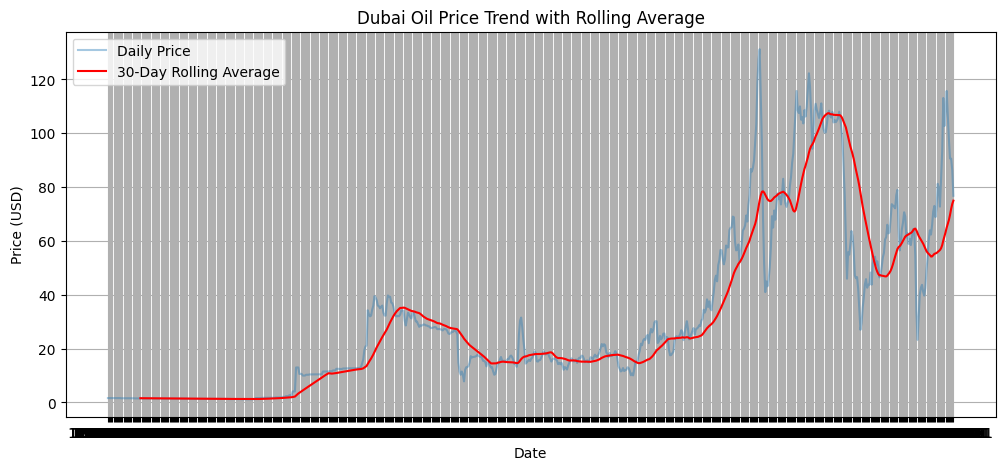

In [ ]:
df['dubai_rolling'] = df['oil_dubai'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['oil_dubai'], alpha=0.4, label='Daily Price')
plt.plot(df['date'], df['dubai_rolling'], color='red', label='30-Day Rolling Average')
plt.title('Dubai Oil Price Trend with Rolling Average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


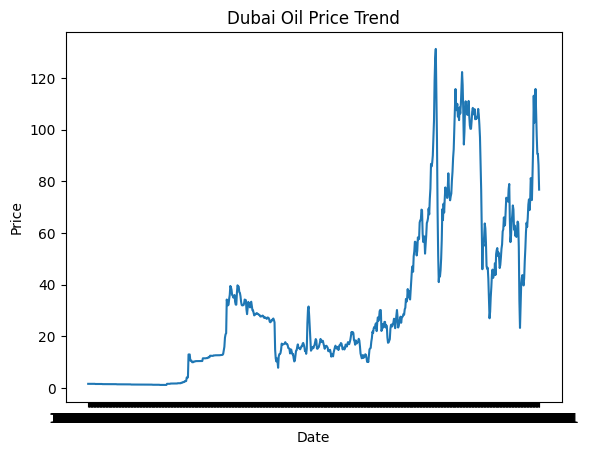

In [ ]:
plt.figure()
plt.plot(df['date'], df['oil_dubai'])

plt.title('Dubai Oil Price Trend')
plt.xlabel('Date')
plt.ylabel('Price')

plt.show()

In [ ]:
df.columns

Index(['Unnamed: 0', 'date', 'oil_brent', 'oil_dubai', 'coffee_arabica',
       'coffee_robustas', 'tea_columbo', 'tea_kolkata', 'tea_mombasa',
       'sugar_eu', 'sugar_us', 'sugar_world', 'diff', 'dubai_rolling'],
      dtype='object')

In [ ]:
commodities = ['oil_brent', 'oil_dubai', 'coffee_arabica', 'coffee_robustas',
       'tea_columbo', 'tea_kolkata', 'tea_mombasa', 'sugar_eu', 'sugar_us',
       'sugar_world']

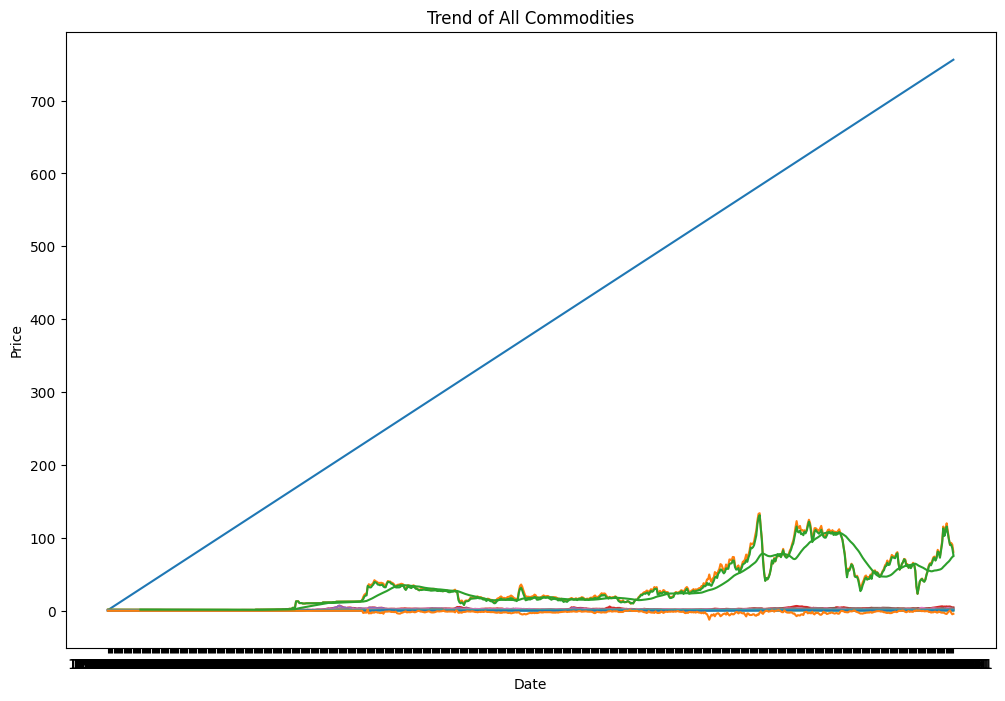

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))

for column in df.columns:
    if column != 'date':
        plt.plot(df['date'], df[column], label=column)
plt.title("Trend of All Commodities")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()